# Statistics in Python: Reproducible Data Analysis

This notebook presents a full reproducible analysis workflow in Python, from data inspection and visualization through hypothesis testing and regression modeling. It begins with the brain-size dataset (`brain_size.csv`), then introduces simple and three-dimensional multiple regression with simulated data, analyzes iris flower measurements (`iris.csv`), models 1985 CPS wages (`wages.txt`), and examines airline fares before and after 9/11 (`airfares.txt`). A companion notebook, `stats_extension.ipynb`, extends the brain-size IQ comparison with a mixed-effects model for repeated within-participant measurements.

## Setup and imports

All required packages are imported once at the start of the notebook.

In [1]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
import pandas as pd
from pandas import plotting
import seaborn as sns
import statsmodels.formula.api as smf
from scipy import stats
from statsmodels.stats.anova import anova_lm

MALE_GENDER_COEF = 'C(Gender)[T.Male]'


### Creating a DataFrame from arrays

Pandas can combine equal-length NumPy arrays into a table in which each column comes from its own array. The short example below generates a sequence of *t* values with corresponding sine and cosine values and displays only the first several rows.

In [2]:
t = np.linspace(-6, 6, 20)
sin_t = np.sin(t)
cos_t = np.cos(t)

trig_table = pd.DataFrame({'t': t, 'sin': sin_t, 'cos': cos_t})

print('DataFrame created from t, sin(t), and cos(t) arrays:')
display(trig_table.head(8))


DataFrame created from t, sin(t), and cos(t) arrays:


,t,sin,cos
0,-6.000000,0.279415,0.960170
1,-5.368421,0.792419,0.609977
2,-4.736842,0.999701,0.024451
3,-4.105263,0.821291,-0.570509
4,-3.473684,0.326021,-0.945363
5,-2.842105,-0.295030,-0.955488
6,-2.210526,-0.802257,-0.596979
7,-1.578947,-0.999967,-0.008151


## Load brain size data

The brain size dataset is read once from `brain_size.csv` into the `brain` DataFrame. Semicolon-separated fields and period (`.`) missing-value codes are handled at import.


In [3]:
brain = pd.read_csv('brain_size.csv', sep=';', na_values='.')
brain = brain.rename(columns={'Unnamed: 0': 'Participant'})
brain.head()


,Participant,Gender,FSIQ,VIQ,PIQ,Weight,Height,MRI_Count
0,1,Female,133,132,124,118.0,64.5,816932
1,2,Male,140,150,124,NaN,72.5,1001121
2,3,Male,139,123,150,143.0,73.3,1038437
3,4,Male,133,129,128,172.0,68.8,965353
4,5,Female,137,132,134,147.0,65.0,951545


## Dataset inspection

Before any statistical analysis, we inspect the structure and quality of the data. This step confirms the sample size, identifies each variable, checks data types, locates missing values, and summarizes the numerical measurements with descriptive statistics.

In [4]:
print('Rows and columns:', brain.shape)
print('\nVariable names:')
print(list(brain.columns))
print('\nData types:')
print(brain.dtypes)
print('\nMissing values per column:')
print(brain.isna().sum())

Rows and columns: (40, 8)

Variable names:
['Participant', 'Gender', 'FSIQ', 'VIQ', 'PIQ', 'Weight', 'Height', 'MRI_Count']

Data types:
Participant      int64
Gender          object
FSIQ             int64
VIQ              int64
PIQ              int64
Weight         float64
Height         float64
MRI_Count        int64
dtype: object

Missing values per column:
Participant    0
Gender         0
FSIQ           0
VIQ            0
PIQ            0
Weight         2
Height         1
MRI_Count      0
dtype: int64


In [5]:
numeric_cols = [
    col for col in brain.select_dtypes(include='number').columns if col != 'Participant'
]
print('Numerical variables:', list(numeric_cols))
brain[numeric_cols].describe()


Numerical variables: ['FSIQ', 'VIQ', 'PIQ', 'Weight', 'Height', 'MRI_Count']


,FSIQ,VIQ,PIQ,Weight,Height,MRI_Count
count,40.000000,40.000000,40.00000,38.000000,39.000000,4.000000e+01
mean,113.450000,112.350000,111.02500,151.052632,68.525641,9.087550e+05
std,24.082071,23.616107,22.47105,23.478509,3.994649,7.228205e+04
min,77.000000,71.000000,72.00000,106.000000,62.000000,7.906190e+05
25%,89.750000,90.000000,88.25000,135.250000,66.000000,8.559185e+05
50%,116.500000,113.000000,115.00000,146.500000,68.000000,9.053990e+05
75%,135.500000,129.750000,128.00000,172.000000,70.500000,9.500780e+05
max,144.000000,150.000000,150.00000,192.000000,77.000000,1.079549e+06


## Summary by gender

The participants are grouped by gender to compare average IQ scores, body measurements, and MRI brain volume counts between female and male subjects in this sample.

In [6]:
summary_cols = ['FSIQ', 'VIQ', 'PIQ', 'Weight', 'Height', 'MRI_Count']

gender_summary = (
    brain.groupby('Gender', sort=True)
    .agg(Participants=('Gender', 'size'), **{col: (col, 'mean') for col in summary_cols})
    .rename(columns={
        'FSIQ': 'Mean FSIQ',
        'VIQ': 'Mean VIQ',
        'PIQ': 'Mean PIQ',
        'Weight': 'Mean Weight',
        'Height': 'Mean Height',
        'MRI_Count': 'Mean MRI Count',
    })
)

gender_summary['Mean ln(MRI Count)'] = (
    brain.groupby('Gender', sort=True)['MRI_Count'].apply(lambda s: np.log(s).mean())
)

gender_summary.round(
    {'Mean Weight': 2, 'Mean Height': 2, 'Mean MRI Count': 0, 'Mean ln(MRI Count)': 4}
)


,Participants,Mean FSIQ,Mean VIQ,Mean PIQ,Mean Weight,Mean Height,Mean MRI Count,Mean ln(MRI Count)
Gender,,,,,,,,
Female,20,111.9,109.45,110.45,137.20,65.76,862655.0,13.6658
Male,20,115.0,115.25,111.60,166.44,71.43,954855.0,13.7677


### Interpretation

This table describes the sample only: we can compare how many participants fall in each gender group and how their average scores and measurements differ. For example, the mean VIQ, PIQ, weight, height, and MRI count can be contrasted between female and male participants. These are observational averages in a small dataset, so they show association rather than proof that gender causes any difference.

## IQ distributions by gender

The next figure compares the distributions of full-scale IQ (FSIQ), verbal IQ (VIQ), and performance IQ (PIQ) between female and male participants using side-by-side boxplots for each IQ measure.

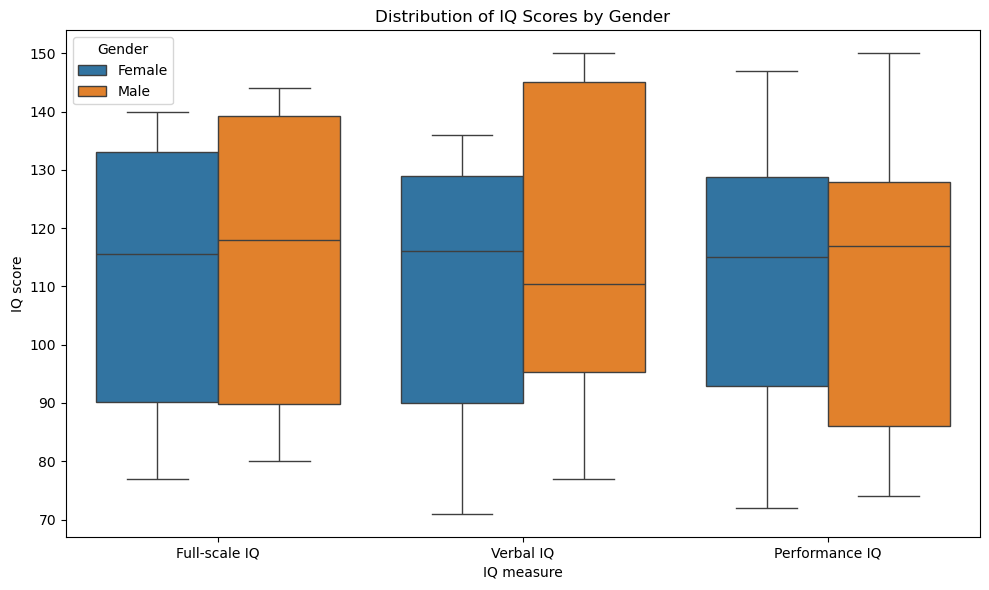

In [7]:
iq_measure_labels = {
    'FSIQ': 'Full-scale IQ',
    'VIQ': 'Verbal IQ',
    'PIQ': 'Performance IQ',
}

iq_boxplot_data = (
    brain.melt(
        id_vars='Gender',
        value_vars=['FSIQ', 'VIQ', 'PIQ'],
        var_name='IQ measure',
        value_name='IQ score',
    )
    .assign(**{'IQ measure': lambda frame: frame['IQ measure'].replace(iq_measure_labels)})
)

plt.figure(figsize=(10, 6))
sns.boxplot(
    data=iq_boxplot_data,
    x='IQ measure',
    y='IQ score',
    hue='Gender',
    order=['Full-scale IQ', 'Verbal IQ', 'Performance IQ'],
)
plt.title('Distribution of IQ Scores by Gender')
plt.xlabel('IQ measure')
plt.ylabel('IQ score')
plt.legend(title='Gender')
plt.tight_layout()
plt.show()

## Body measurements and MRI count

The next figure examines the distributions of weight, height, and MRI count and the pairwise relationships between each pair of these variables. A scatter matrix shows histograms on the diagonal and scatter plots for every off-diagonal pair.

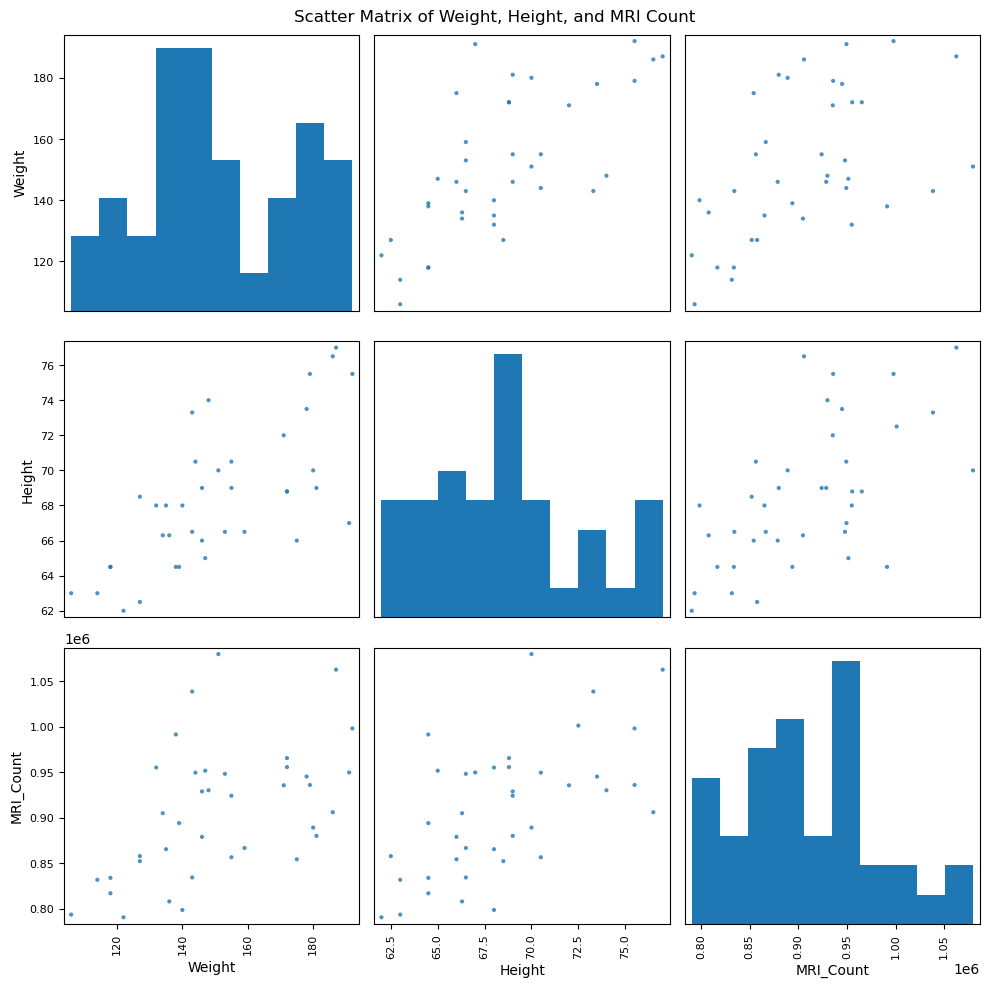

In [8]:
body_vars = brain[['Weight', 'Height', 'MRI_Count']]

plotting.scatter_matrix(body_vars, alpha=0.8, figsize=(10, 10), diagonal='hist')
plt.suptitle('Scatter Matrix of Weight, Height, and MRI Count', y=0.98)
plt.tight_layout()
plt.show()

## Relationships among IQ measures

The next figure examines how full-scale IQ, verbal IQ, and performance IQ relate to one another across all participants. A scatter matrix shows the distribution of each IQ measure on the diagonal and pairwise scatter plots off the diagonal, without separating participants by gender.

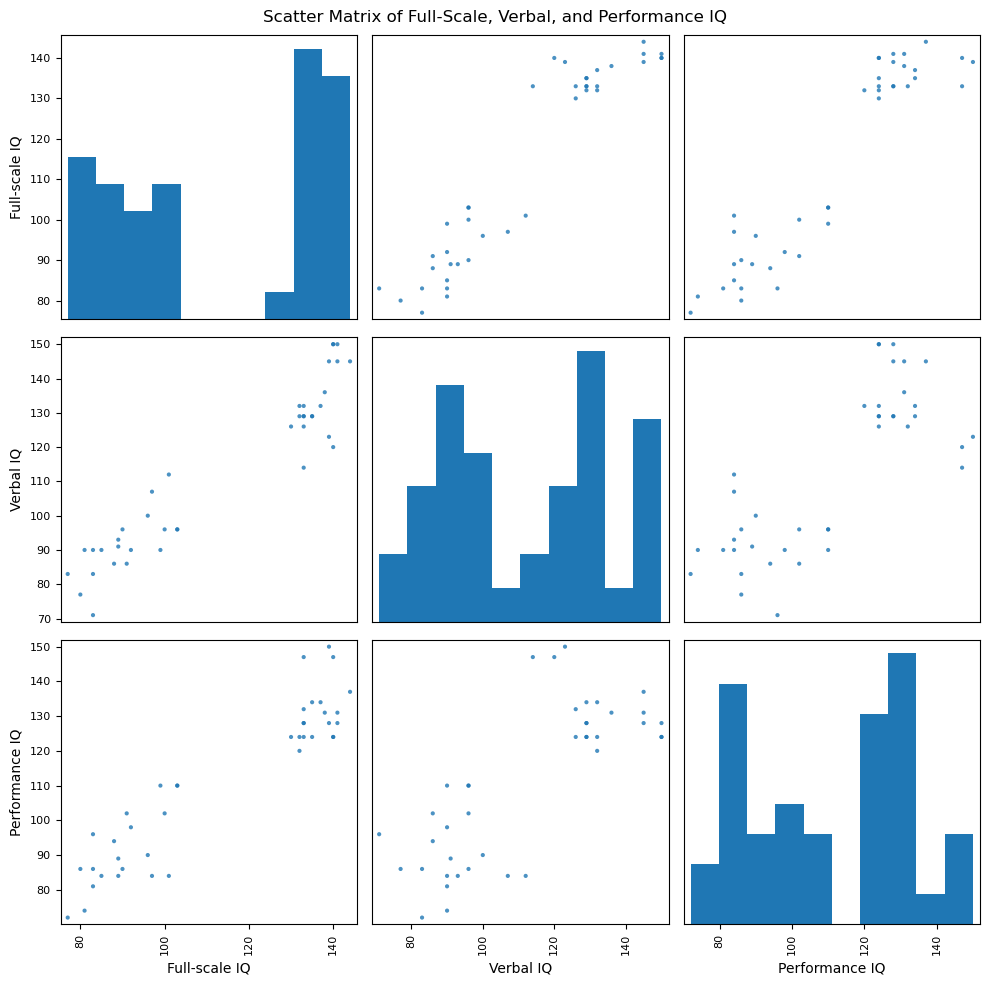

In [9]:
iq_vars = brain[['FSIQ', 'VIQ', 'PIQ']].rename(
    columns={
        'FSIQ': 'Full-scale IQ',
        'VIQ': 'Verbal IQ',
        'PIQ': 'Performance IQ',
    }
)

plotting.scatter_matrix(iq_vars, alpha=0.8, figsize=(10, 10), diagonal='hist')
plt.suptitle('Scatter Matrix of Full-Scale, Verbal, and Performance IQ', y=0.98)
plt.tight_layout()
plt.show()

## IQ relationships among female participants

Descriptive summaries above show sample-average IQ scores that differ numerically between female and male participants, but the independent *t*-test on verbal IQ did not reject the null of equal means. Examining full-scale, verbal, and performance IQ only within female participants can still be useful: it removes mixing with the male subgroup and makes it easier to see how these three measures relate to one another in one gender group.


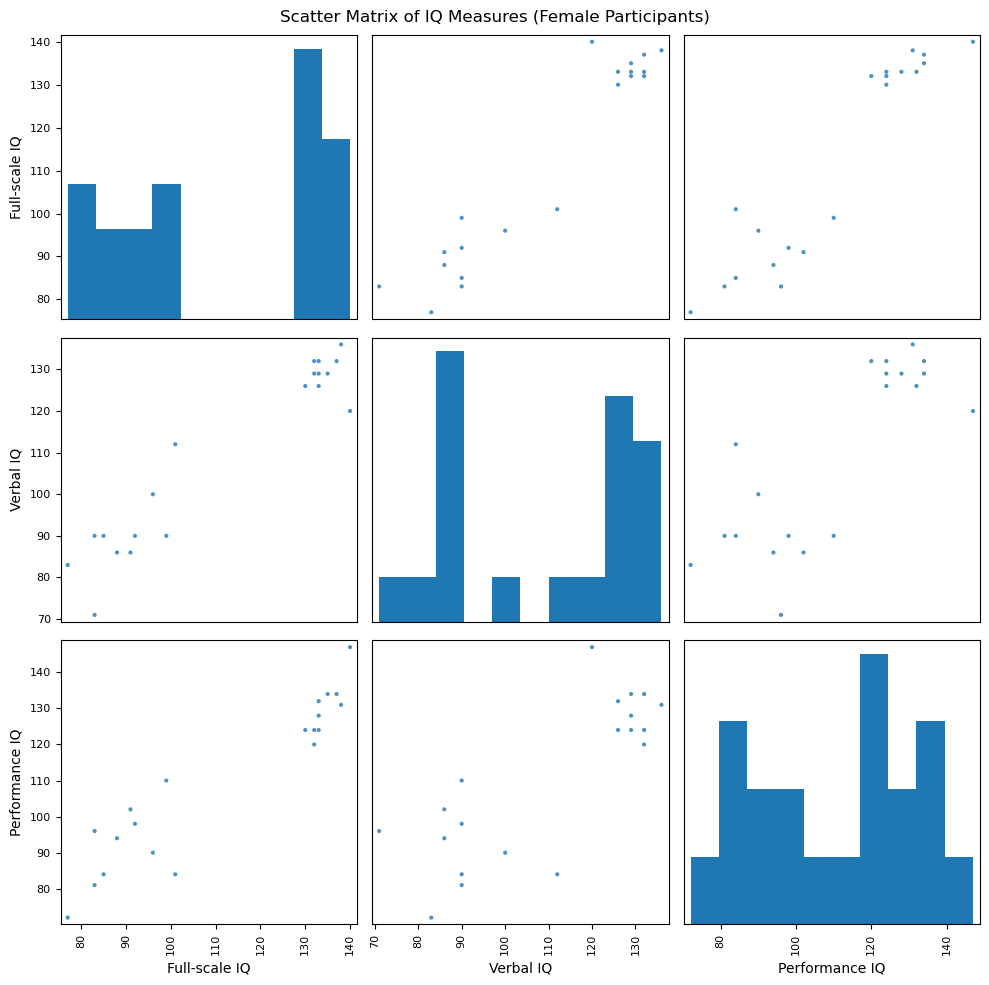

In [10]:
female_iq = brain.loc[brain['Gender'] == 'Female', ['FSIQ', 'VIQ', 'PIQ']].rename(
    columns={
        'FSIQ': 'Full-scale IQ',
        'VIQ': 'Verbal IQ',
        'PIQ': 'Performance IQ',
    }
)

plotting.scatter_matrix(female_iq, alpha=0.8, figsize=(10, 10), diagonal='hist')
plt.suptitle('Scatter Matrix of IQ Measures (Female Participants)', y=0.98)
plt.tight_layout()
plt.show()

## IQ relationships among male participants

The same relationships among full-scale IQ, verbal IQ, and performance IQ will now be examined within male participants only. This figure uses the same three measures and layout as the female scatter matrix, so the two gender-specific plots can be compared side by side.

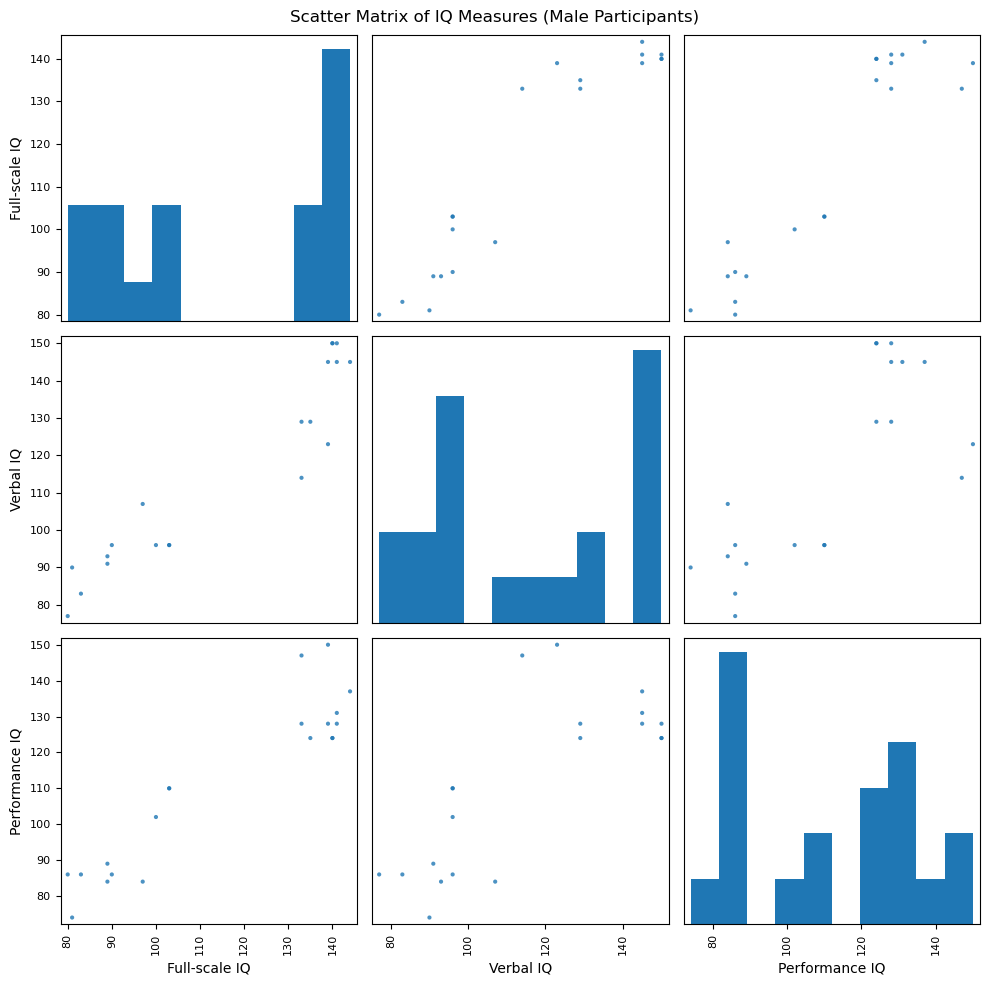

In [11]:
male_iq = brain.loc[brain['Gender'] == 'Male', ['FSIQ', 'VIQ', 'PIQ']].rename(
    columns={
        'FSIQ': 'Full-scale IQ',
        'VIQ': 'Verbal IQ',
        'PIQ': 'Performance IQ',
    }
)

plotting.scatter_matrix(male_iq, alpha=0.8, figsize=(10, 10), diagonal='hist')
plt.suptitle('Scatter Matrix of IQ Measures (Male Participants)', y=0.98)
plt.tight_layout()
plt.show()

## One-sample *t*-test (method example)

A one-sample *t*-test asks whether the mean of a single sample differs from a specified reference value. Here we use verbal IQ (VIQ) to demonstrate the procedure by testing against zero:

- **Null hypothesis (H₀):** The population mean of verbal IQ equals 0 (μ = 0).
- **Alternative hypothesis (H₁):** The population mean of verbal IQ is not equal to 0 (μ ≠ 0).

Zero is not a scientifically meaningful reference for IQ scores, which are scaled to have a population mean near 100. The analysis below is therefore mainly a methodological illustration of how to run and report a one-sample *t*-test in Python.

In [12]:
viq = brain['VIQ']
sample_mean = viq.mean()
t_statistic, p_value = stats.ttest_1samp(viq, popmean=0)

print(f'Sample mean verbal IQ: {sample_mean:.2f}')
print(f't statistic: {t_statistic:.4f}')
print(f'p-value: {p_value:.4e}')

print(
    '\nInterpretation: The sample mean is far above zero, so the test strongly '
    'rejects H₀. That result is expected because IQ scores are not centered on '
    'zero. This step demonstrates the one-sample *t*-test workflow rather than '
    'answering a substantive research question.'
)

Sample mean verbal IQ: 112.35
t statistic: 30.0881
p-value: 1.3289e-28

Interpretation: The sample mean is far above zero, so the test strongly rejects H₀. That result is expected because IQ scores are not centered on zero. This step demonstrates the one-sample *t*-test workflow rather than answering a substantive research question.


## Does verbal IQ differ between female and male participants?

We next ask whether mean verbal IQ (VIQ) differs between female and male participants using an independent-samples *t*-test:

- **Null hypothesis (H₀):** Mean verbal IQ is the same for female and male participants (μ_female = μ_male).
- **Alternative hypothesis (H₁):** Mean verbal IQ differs between female and male participants (μ_female ≠ μ_male).

The two gender groups are treated as **independent** because each participant belongs to only one group and was measured once; one person's VIQ score does not determine another person's score across groups.

In [13]:
female_viq = brain.loc[brain['Gender'] == 'Female', 'VIQ']
male_viq = brain.loc[brain['Gender'] == 'Male', 'VIQ']

female_n = female_viq.size
male_n = male_viq.size
female_mean = female_viq.mean()
male_mean = male_viq.mean()

t_statistic, p_value = stats.ttest_ind(female_viq, male_viq)

print(f'Female: n = {female_n}, mean VIQ = {female_mean:.2f}')
print(f'Male:   n = {male_n}, mean VIQ = {male_mean:.2f}')
print(f't statistic: {t_statistic:.4f}')
print(f'p-value: {p_value:.4f}')

if p_value < 0.05:
    print(
        '\nInterpretation: The p-value is below 0.05, so we reject H₀ and conclude '
        'that mean verbal IQ differs between female and male participants in this sample.'
    )
else:
    print(
        '\nInterpretation: The p-value is not below 0.05, so we do not reject H₀. '
        'This sample does not provide strong evidence that mean verbal IQ differs '
        'between female and male participants.'
    )

Female: n = 20, mean VIQ = 109.45
Male:   n = 20, mean VIQ = 115.25
t statistic: -0.7726
p-value: 0.4445

Interpretation: The p-value is not below 0.05, so we do not reject H₀. This sample does not provide strong evidence that mean verbal IQ differs between female and male participants.


## Independent-samples *t*-test: full-scale IQ vs. performance IQ (method caution)

For comparison, we can apply an independent-samples *t*-test to full-scale IQ (FSIQ) and performance IQ (PIQ) as if they were two unrelated groups. This step is mainly a methodological illustration: FSIQ and PIQ were measured on the **same participants**, so the scores are paired rather than independent. Treating them as separate samples ignores within-person correlation and is **not the most suitable design** for this question; a paired *t*-test would be the appropriate alternative.

In [14]:
fsiq_mean = brain['FSIQ'].mean()
piq_mean = brain['PIQ'].mean()
t_statistic, p_value = stats.ttest_ind(brain['FSIQ'], brain['PIQ'])

print(f'Mean full-scale IQ (FSIQ): {fsiq_mean:.2f}')
print(f'Mean performance IQ (PIQ): {piq_mean:.2f}')
print(f't statistic: {t_statistic:.4f}')
print(f'p-value: {p_value:.4f}')

print(
    '\nNote: Although this output reports an independent-samples test, FSIQ and PIQ '
    'come from the same people. The independent approach therefore does not match '
    'the study design and should not be used as the primary inference method here.'
)

Mean full-scale IQ (FSIQ): 113.45
Mean performance IQ (PIQ): 111.03
t statistic: 0.4656
p-value: 0.6428

Note: Although this output reports an independent-samples test, FSIQ and PIQ come from the same people. The independent approach therefore does not match the study design and should not be used as the primary inference method here.


## Paired-samples *t*-test: full-scale IQ vs. performance IQ

Because FSIQ and PIQ were measured on the **same participants**, the appropriate primary comparison is a paired-samples *t*-test:

- **Null hypothesis (H₀):** Mean FSIQ − PIQ difference equals zero (μ_diff = 0).
- **Alternative hypothesis (H₁):** Mean FSIQ − PIQ difference is not zero (μ_diff ≠ 0).

This test uses within-person pairing and is the correct inferential counterpart to the participant-level difference analyzed next.

In [15]:
fsiq = brain['FSIQ']
piq = brain['PIQ']
mean_fsiq = fsiq.mean()
mean_piq = piq.mean()
t_statistic, p_value = stats.ttest_rel(fsiq, piq)

print(f'Mean full-scale IQ (FSIQ): {mean_fsiq:.2f}')
print(f'Mean performance IQ (PIQ): {mean_piq:.2f}')
print(f'Paired *t*-statistic: {t_statistic:.4f}')
print(f'p-value: {p_value:.4f}')
if p_value < 0.05:
    print(
        'Interpretation: The p-value is below 0.05, so we reject H₀ and conclude that '
        'mean FSIQ and PIQ differ in this paired sample.'
    )
else:
    print(
        'Interpretation: The p-value is not below 0.05, so we do not reject H₀. '
        'This sample does not provide strong evidence of a mean difference between FSIQ and PIQ.'
    )

Mean full-scale IQ (FSIQ): 113.45
Mean performance IQ (PIQ): 111.03
Paired *t*-statistic: 1.7842
p-value: 0.0822
Interpretation: The p-value is not below 0.05, so we do not reject H₀. This sample does not provide strong evidence of a mean difference between FSIQ and PIQ.


## Boxplots for full-scale IQ, performance IQ, and their paired difference

The first figure compares the marginal distributions of FSIQ and PIQ across participants. The second figure summarizes the participant-level FSIQ − PIQ differences that enter the paired and one-sample tests.

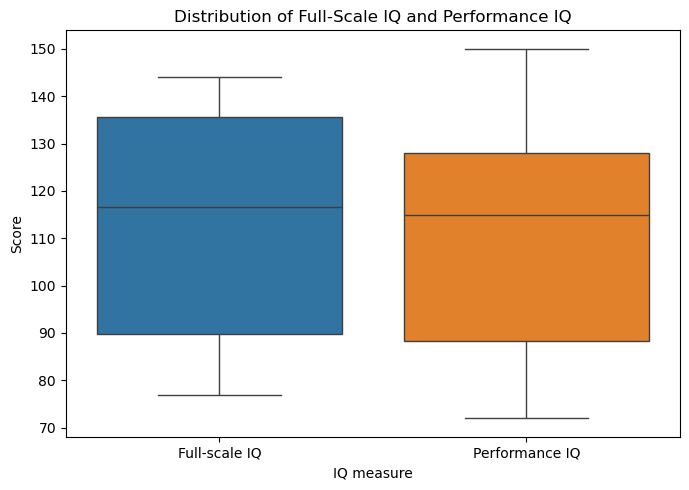

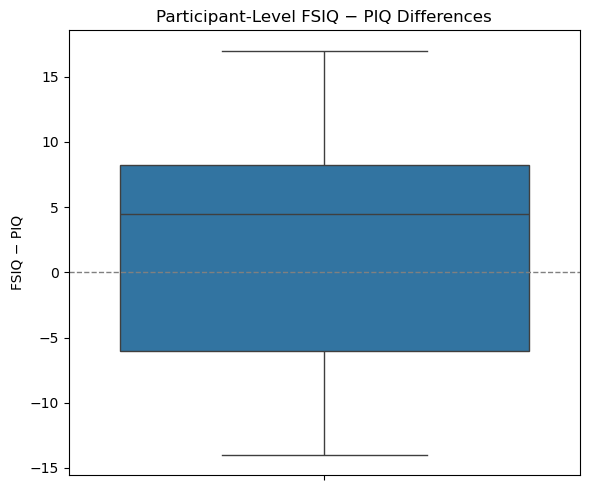

In [16]:
fsiq_piq_box = brain[['FSIQ', 'PIQ']].melt(
    var_name='IQ measure',
    value_name='Score',
)
iq_measure_labels = {'FSIQ': 'Full-scale IQ', 'PIQ': 'Performance IQ'}
fsiq_piq_box['IQ measure'] = fsiq_piq_box['IQ measure'].map(iq_measure_labels)

plt.figure(figsize=(7, 5))
sns.boxplot(data=fsiq_piq_box, x='IQ measure', y='Score', hue='IQ measure', legend=False)
plt.title('Distribution of Full-Scale IQ and Performance IQ')
plt.xlabel('IQ measure')
plt.ylabel('Score')
plt.tight_layout()
plt.show()

fsiq_piq_diff = brain['FSIQ'] - brain['PIQ']

plt.figure(figsize=(6, 5))
sns.boxplot(y=fsiq_piq_diff)
plt.axhline(0, color='gray', linestyle='--', linewidth=1)
plt.title('Participant-Level FSIQ − PIQ Differences')
plt.ylabel('FSIQ − PIQ')
plt.tight_layout()
plt.show()


## Participant-level FSIQ − PIQ difference (one-sample test)

An equivalent way to analyze the paired comparison above is to compute each person's difference (FSIQ − PIQ) and test whether the mean difference differs from zero with a one-sample *t*-test (H₀: μ_diff = 0).

This approach gives the **same test statistic and p-value as the paired-samples *t*-test** on FSIQ and PIQ because both methods compare within-person scores and test the same null hypothesis about the mean paired difference.


In [17]:
# Reuse participant-level differences created for the boxplots above.
mean_diff = fsiq_piq_diff.mean()
t_statistic, p_value = stats.ttest_1samp(fsiq_piq_diff, popmean=0)

print(f'Mean FSIQ − PIQ difference: {mean_diff:.2f}')
print(f't statistic: {t_statistic:.4f}')
print(f'p-value: {p_value:.4f}')

print(
    '\nThis one-sample test on participant-level differences is equivalent to a '
    'paired-samples *t*-test, so the test statistic and p-value should match '
    'that paired analysis.'
)


Mean FSIQ − PIQ difference: 2.42
t statistic: 1.7842
p-value: 0.0822

This one-sample test on participant-level differences is equivalent to a paired-samples *t*-test, so the test statistic and p-value should match that paired analysis.


## Nonparametric paired comparison: Wilcoxon signed-rank test

When paired measurements may not meet normality assumptions, or when we prefer a rank-based method, the **Wilcoxon signed-rank test** compares full-scale IQ and performance IQ within participants without assuming a normal distribution of differences. It uses the signs and magnitudes of within-person differences rather than the raw mean difference tested by a paired *t*-test.

In [18]:
statistic, p_value = stats.wilcoxon(brain['FSIQ'], brain['PIQ'])

print(f'Wilcoxon statistic: {statistic:.4f}')
print(f'p-value: {p_value:.4f}')

print(
    '\nUnlike the paired *t*-test, the signed-rank test does not assume normally '
    'distributed differences and focuses on ranked within-person changes. It can be '
    'useful with small samples, skewed difference scores, or outliers.'
)

Wilcoxon statistic: 274.5000
p-value: 0.1066

Unlike the paired *t*-test, the signed-rank test does not assume normally distributed differences and focuses on ranked within-person changes. It can be useful with small samples, skewed difference scores, or outliers.


## Does body weight differ between female and male participants?

We test whether mean body weight differs between female and male participants using an independent-samples *t*-test. Only rows with missing weight are excluded for this analysis; all other variables are retained for participants with observed weight.

In [19]:
weight_data = brain.dropna(subset=['Weight'])
female_weight = weight_data.loc[weight_data['Gender'] == 'Female', 'Weight']
male_weight = weight_data.loc[weight_data['Gender'] == 'Male', 'Weight']

t_statistic, p_value = stats.ttest_ind(female_weight, male_weight)

print(f'Female: n = {female_weight.size}, mean weight = {female_weight.mean():.2f}')
print(f'Male:   n = {male_weight.size}, mean weight = {male_weight.mean():.2f}')
print(f't statistic: {t_statistic:.4f}')
print(f'p-value: {p_value:.4e}')

print(
    '\nInterpretation: The p-value is well below 0.05, so we reject the null '
    'hypothesis of equal mean weight and conclude that body weight differs '
    'between female and male participants in this sample.'
)

Female: n = 20, mean weight = 137.20
Male:   n = 18, mean weight = 166.44
t statistic: -4.8710
p-value: 2.2273e-05

Interpretation: The p-value is well below 0.05, so we reject the null hypothesis of equal mean weight and conclude that body weight differs between female and male participants in this sample.


## Nonparametric comparison of verbal IQ by gender

As a rank-based alternative to the earlier independent-samples *t*-test, we apply the **Mann–Whitney U test** (Wilcoxon rank-sum test) to compare verbal IQ between female and male participants. This method compares the distributions of the two independent groups without assuming normality.

In [20]:
statistic, p_value = stats.mannwhitneyu(female_viq, male_viq, alternative='two-sided')

print(f'Mann–Whitney U statistic: {statistic:.4f}')
print(f'p-value: {p_value:.4f}')

print(
    '\nInterpretation: The p-value is not below 0.05, so we do not reject the null '
    'hypothesis that verbal IQ distributions are similar between female and male '
    'participants in this sample.'
)

print(
    '\nUnlike the independent-samples *t*-test, the Mann–Whitney U test uses ranks '
    'rather than means and does not assume normally distributed scores. It can be '
    'useful when sample sizes are small or distributions are skewed.'
)

Mann–Whitney U statistic: 164.5000
p-value: 0.3423

Interpretation: The p-value is not below 0.05, so we do not reject the null hypothesis that verbal IQ distributions are similar between female and male participants in this sample.

Unlike the independent-samples *t*-test, the Mann–Whitney U test uses ranks rather than means and does not assume normally distributed scores. It can be useful when sample sizes are small or distributions are skewed.


## Linear regression: verbal IQ predicted by gender

Linear regression models the mean value of an outcome as a function of predictors. Here we regress verbal IQ (VIQ) on gender treated as a categorical predictor, which estimates the mean VIQ for the reference gender and the mean difference for the other gender.

In [21]:
brain_viq_gender_model = smf.ols('VIQ ~ C(Gender)', data=brain).fit()
print(brain_viq_gender_model.summary())

male_coef_name = MALE_GENDER_COEF
print('\nReference gender: Female (baseline category).')
print(
    f'Intercept: estimated mean VIQ for female participants = '
    f'{brain_viq_gender_model.params["Intercept"]:.2f}'
)
print(
    f'Gender coefficient (Male vs Female): {brain_viq_gender_model.params[male_coef_name]:.2f} '
    f'(p = {brain_viq_gender_model.pvalues[male_coef_name]:.4f})'
)
print(
    f'R-squared: {brain_viq_gender_model.rsquared:.4f} — about '
    f'{100 * brain_viq_gender_model.rsquared:.1f}% of VIQ variance is explained by gender alone.'
)

                            OLS Regression Results                            
Dep. Variable:                    VIQ   R-squared:                       0.015
Model:                            OLS   Adj. R-squared:                 -0.010
Method:                 Least Squares   F-statistic:                    0.5969
Date:                Mon, 27 Jul 2026   Prob (F-statistic):              0.445
Time:                        21:50:32   Log-Likelihood:                -182.42
No. Observations:                  40   AIC:                             368.8
Df Residuals:                      38   BIC:                             372.2
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept           109.4500      5.30

## Reshaping full-scale IQ and performance IQ to long format

In the wide dataset, each participant has one row with separate columns for full-scale IQ (FSIQ) and performance IQ (PIQ). For regression with measurement type as a predictor, we reshape to **long format** so each IQ score occupies its own row. This stacked structure makes it possible to compare the two measurement types while keeping a participant identifier on every row.

The ordinary least-squares model below treats the two IQ rows as independent observations. It therefore corresponds to the **independent** FSIQ versus PIQ comparison and does not account for within-participant correlation. A mixed-effects extension that adds random intercepts by participant is shown in `stats_extension.ipynb`.


In [22]:
fsiq_piq_long = (
    brain[['Participant', 'FSIQ', 'PIQ']]
    .melt(
        id_vars='Participant',
        value_vars=['FSIQ', 'PIQ'],
        var_name='IQ measurement type',
        value_name='IQ value',
    )
)

print('First rows of the long-format IQ table:')
display(fsiq_piq_long.head(8))

brain_iq_ols_model = smf.ols(
    'Q("IQ value") ~ C(Q("IQ measurement type"))',
    data=fsiq_piq_long,
).fit()
print(brain_iq_ols_model.summary())

piq_coef_name = 'C(Q("IQ measurement type"))[T.PIQ]'
print(
    f'\nReference measurement type: FSIQ. The PIQ coefficient '
    f'({brain_iq_ols_model.params[piq_coef_name]:.2f}) is the estimated mean difference '
    f'PIQ − FSIQ under the independent-groups OLS specification.'
)


First rows of the long-format IQ table:


,Participant,IQ measurement type,IQ value
0,1,FSIQ,133
1,2,FSIQ,140
2,3,FSIQ,139
3,4,FSIQ,133
4,5,FSIQ,137
5,6,FSIQ,99
6,7,FSIQ,138
7,8,FSIQ,92


                            OLS Regression Results                            
Dep. Variable:          Q("IQ value")   R-squared:                       0.003
Model:                            OLS   Adj. R-squared:                 -0.010
Method:                 Least Squares   F-statistic:                    0.2168
Date:                Mon, 27 Jul 2026   Prob (F-statistic):              0.643
Time:                        21:50:32   Log-Likelihood:                -364.35
No. Observations:                  80   AIC:                             732.7
Df Residuals:                      78   BIC:                             737.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                                         coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------------
Inte

## Multiple linear regression: verbal IQ with gender, MRI count, and height

We fit a multiple linear regression model with verbal IQ as the outcome and gender (categorical), MRI count, and height as predictors. Only participants with complete values on all model variables are included; missing values are not imputed from other participants. The coefficients describe **associations** in this sample and should not be interpreted as causal effects.

In [23]:
model_vars = ['VIQ', 'Gender', 'MRI_Count', 'Height']
brain_model_data = brain.dropna(subset=model_vars)

brain_viq_multi_model = smf.ols('VIQ ~ C(Gender) + MRI_Count + Height', data=brain_model_data).fit()
print(brain_viq_multi_model.summary())

male_coef_name = MALE_GENDER_COEF
print(
    f'\nGender (Male vs Female): {brain_viq_multi_model.params[male_coef_name]:.4f} '
    f'(p = {brain_viq_multi_model.pvalues[male_coef_name]:.4f}) — associated VIQ difference '
    f'for male participants relative to female, holding MRI count and height constant.'
)
print(
    f'MRI count: {brain_viq_multi_model.params["MRI_Count"]:.6f} '
    f'(p = {brain_viq_multi_model.pvalues["MRI_Count"]:.4f}) — change in VIQ associated with '
    f'each additional unit of MRI count, holding gender and height constant.'
)
print(
    f'Height: {brain_viq_multi_model.params["Height"]:.4f} '
    f'(p = {brain_viq_multi_model.pvalues["Height"]:.4f}) — change in VIQ associated with each '
    f'one-unit increase in height, holding gender and MRI count constant.'
)
print(
    f'\nR-squared: {brain_viq_multi_model.rsquared:.4f} — about {100 * brain_viq_multi_model.rsquared:.1f}% '
    f'of VIQ variance is explained by gender, MRI count, and height together in this sample.'
)
print(
    '\nThese results describe statistical associations only and do not establish causal '
    'relationships between the predictors and verbal IQ.'
)
print(
    '\nNote on the large condition number: statsmodels warns when predictor scales differ '
    'substantially (here, MRI count is on the order of 10^6 while height is near 70). '
    'That ill-conditioning can inflate numerical sensitivity of coefficient estimates even '
    'when inference remains usable; centering or rescaling predictors would reduce the warning.'
)


                            OLS Regression Results                            
Dep. Variable:                    VIQ   R-squared:                       0.246
Model:                            OLS   Adj. R-squared:                  0.181
Method:                 Least Squares   F-statistic:                     3.809
Date:                Mon, 27 Jul 2026   Prob (F-statistic):             0.0184
Time:                        21:50:32   Log-Likelihood:                -172.34
No. Observations:                  39   AIC:                             352.7
Df Residuals:                      35   BIC:                             359.3
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept           166.6258     88.82

## F-test for the gender coefficient

We test whether the gender coefficient in the multiple regression model equals zero using an *F*-test on the fitted model from the previous section:

- **Null hypothesis (H₀):** The gender coefficient is zero (no mean VIQ difference between male and female participants after adjusting for MRI count and height).

This *F*-test assesses the same gender effect reported in the regression summary table.

In [24]:
gender_f_test = brain_viq_multi_model.f_test('C(Gender)[T.Male] = 0')
print(gender_f_test)

f_stat = float(gender_f_test.fvalue)
f_pvalue = float(gender_f_test.pvalue)

print(
    f'\nThe F statistic ({f_stat:.4f}) and p-value ({f_pvalue:.4f}) match the '
    f'inference for the gender coefficient in the regression summary '
    f'(t = {brain_viq_multi_model.tvalues[male_coef_name]:.4f}, '
    f'p = {brain_viq_multi_model.pvalues[male_coef_name]:.4f}). For a single coefficient, '
    f'F equals t squared.'
)

<F test: F=0.6831960845842314, p=0.4140878441244694, df_denom=35, df_num=1>

The F statistic (0.6832) and p-value (0.4141) match the inference for the gender coefficient in the regression summary (t = 0.8266, p = 0.4141). For a single coefficient, F equals t squared.


## Visualizing predictors in the multiple regression model

The multiple regression model relates verbal IQ to gender, MRI count, and height. A scatter-matrix view of the three continuous variables, with points colored by gender, helps inspect the associations and overlaps among predictors and the outcome using the same complete-case participants included in that model.

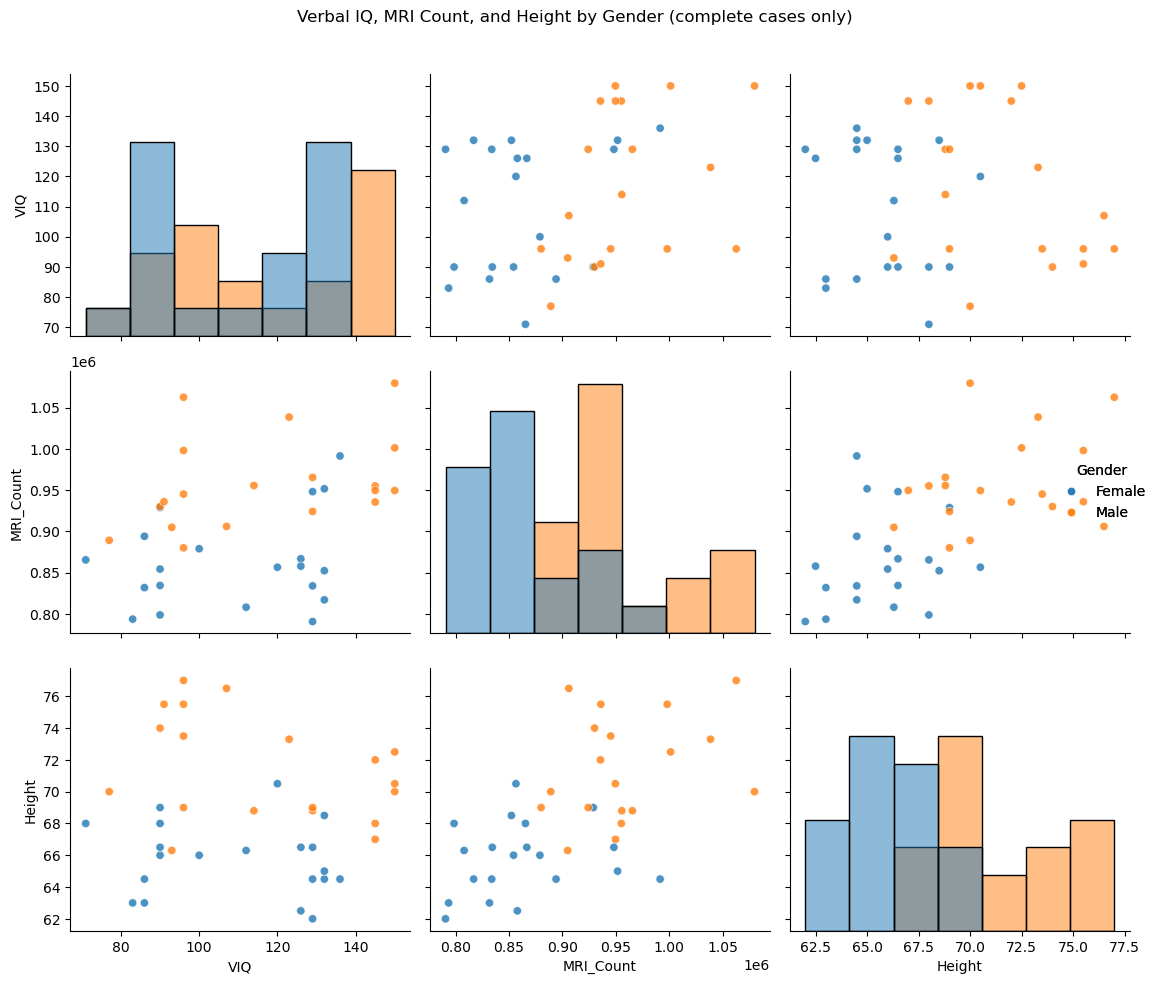

In [25]:
regression_plot_data = brain_model_data[['VIQ', 'MRI_Count', 'Height', 'Gender']]

pairplot_grid = sns.pairplot(
    regression_plot_data,
    vars=['VIQ', 'MRI_Count', 'Height'],
    hue='Gender',
    diag_kind='hist',
    plot_kws={'alpha': 0.8},
    height=3.2,
)
pairplot_grid.fig.suptitle(
    'Verbal IQ, MRI Count, and Height by Gender (complete cases only)',
    y=1.02,
)
pairplot_grid.add_legend(title='Gender')
plt.tight_layout()
plt.show()

## Simple linear regression with simulated data

Simple linear regression models a continuous outcome *y* as a linear function of a predictor *x* (y = β₀ + β₁x + ε). To illustrate the method in a fully reproducible setting, we generate a small simulated dataset in which *y* follows a linear relationship with *x* plus random noise. A fixed random seed ensures the same data every time this notebook is run.

This section is an independently generated AI analysis. Its numerical output therefore differs from the SciPy walkthrough example, which uses `np.random.seed(1)`, *x* values from −5 to 5, and *y* = −5 + 3*x* + 4ε. Here we instead use seed **42**, *x* from 1 to 10, intercept **2.0**, slope **3.5**, and noise scale **2.0**. Those differences are intentional and do not indicate an error in either analysis.

In [26]:
rng = np.random.default_rng(42)
n_obs = 20
x_sim = np.linspace(1, 10, n_obs)
true_intercept = 2.0
true_slope = 3.5
y_sim = true_intercept + true_slope * x_sim + rng.normal(0, 2.0, size=n_obs)

sim_data = pd.DataFrame({'x': x_sim, 'y': y_sim})
sim_data.head()


,x,y
0,1.000000,6.109434
1,1.473684,5.077927
2,1.947368,10.316692
3,2.421053,12.354814
4,2.894737,8.229509


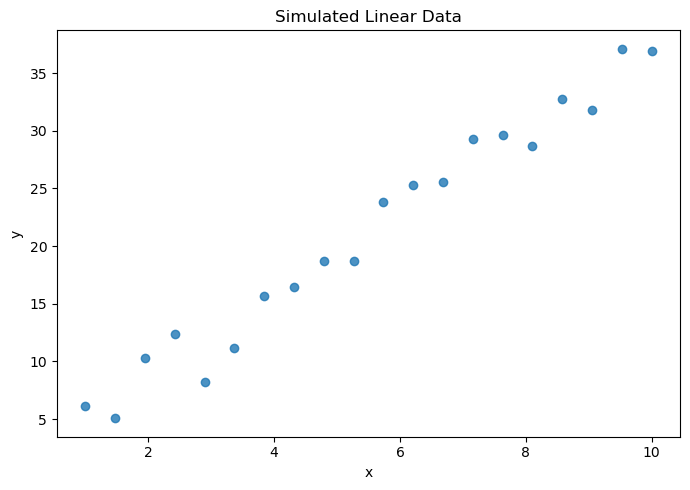

In [27]:
plt.figure(figsize=(7, 5))
plt.scatter(sim_data['x'], sim_data['y'], alpha=0.8, label='Simulated observations')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Simulated Linear Data')
plt.tight_layout()
plt.show()


In [28]:
sim_ols_model = smf.ols('y ~ x', data=sim_data).fit()
print(sim_ols_model.summary())

print(f"\nEstimated intercept: {sim_ols_model.params['Intercept']:.4f}")
print(f"Estimated slope: {sim_ols_model.params['x']:.4f}")

print('\nAnalysis of variance:')
print(anova_lm(sim_ols_model))


                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.972
Model:                            OLS   Adj. R-squared:                  0.970
Method:                 Least Squares   F-statistic:                     625.9
Date:                Mon, 27 Jul 2026   Prob (F-statistic):           1.96e-15
Time:                        21:50:35   Log-Likelihood:                -38.645
No. Observations:                  20   AIC:                             81.29
Df Residuals:                      18   BIC:                             83.28
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      1.3447      0.885      1.519      0.1

### Interpretation

The intercept estimates the expected value of *y* when *x* = 0, and the slope estimates the average change in *y* per one-unit increase in *x*. The model *R*-squared indicates how much of the variation in *y* is explained by *x* in this simulated sample. The ANOVA table partitions the total sum of squares into the portion explained by the regression and the residual (unexplained) variation, and tests whether the linear relationship is statistically significant overall.

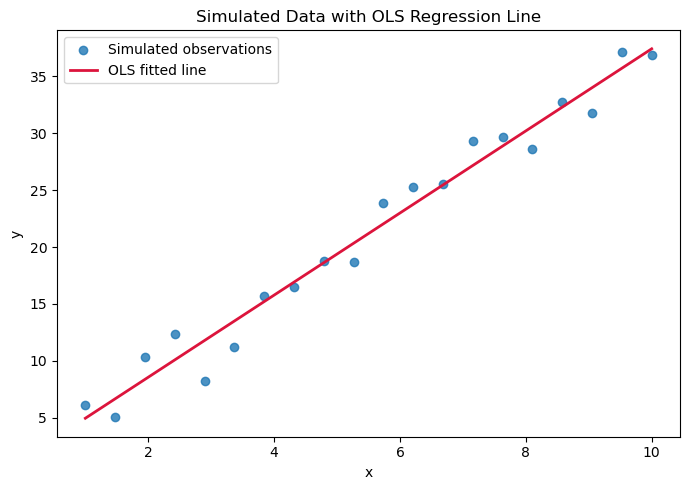

In [29]:
x_line = np.linspace(sim_data['x'].min(), sim_data['x'].max(), 100)
y_line = sim_ols_model.params['Intercept'] + sim_ols_model.params['x'] * x_line

plt.figure(figsize=(7, 5))
plt.scatter(sim_data['x'], sim_data['y'], alpha=0.8, label='Simulated observations')
plt.plot(x_line, y_line, color='crimson', linewidth=2, label='OLS fitted line')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Simulated Data with OLS Regression Line')
plt.legend()
plt.tight_layout()
plt.show()


## Multiple Regression in Three Dimensions

When a response depends on **two continuous predictors**, multiple linear regression extends the straight-line idea from simple regression into three-dimensional space. Each observation has coordinates (*x*, *y*, *z*), where *z* is the outcome and *x* and *y* are explanatory variables. A model of the form *z* = β₀ + β₁*x* + β₂*y* + ε describes a **plane** rather than a line: the intercept β₀ sets the level of the plane when both predictors equal zero, β₁ gives the change in *z* per one-unit increase in *x* (holding *y* fixed), and β₂ gives the change in *z* per one-unit increase in *y* (holding *x* fixed). Plotting the data in 3D makes this geometry visible—the scattered points are the observations, and the fitted regression surface is the best-fitting plane through that cloud.

The reproducible example below follows the SciPy walkthrough setup. Each predictor takes **21 evenly spaced values from −5 to 5**, arranged on a two-dimensional grid. With random seed **1**, the response is generated as

*z* = −5 + 3*x* − 0.5*y* + ε, ε ~ Normal(0, 8²),

so the true intercept is −5, the *x* coefficient is 3, the *y* coefficient is −0.5, and the noise has scale 8. After fitting ordinary least squares, we visualize the observations together with the fitted regression plane.

In [30]:
# Reproducible 2D grid matching the SciPy walkthrough
reg3d_axis = np.linspace(-5, 5, 21)
reg3d_X_grid, reg3d_Y_grid = np.meshgrid(reg3d_axis, reg3d_axis)

reg3d_intercept = -5
reg3d_x_coef = 3
reg3d_y_coef = -0.5
reg3d_noise_scale = 8

np.random.seed(1)
reg3d_Z_grid = (
    reg3d_intercept
    + reg3d_x_coef * reg3d_X_grid
    + reg3d_y_coef * reg3d_Y_grid
    + reg3d_noise_scale * np.random.normal(size=reg3d_X_grid.shape)
)


### Fitting z ~ x + y on the tabular data

The 2D grid layout is not used directly by the regression formula interface. We therefore flatten the simulated *x*, *y*, and *z* values into a long table, fit ordinary least squares with both predictors, and summarize the estimated coefficients and analysis-of-variance table.

In [31]:
reg3d_data = pd.DataFrame(
    {
        'x': reg3d_X_grid.flatten(),
        'y': reg3d_Y_grid.flatten(),
        'z': reg3d_Z_grid.flatten(),
    }
)

print('Tabular data (first 10 rows):')
display(reg3d_data.head(10))
print(f'\nShape: {reg3d_data.shape[0]} rows × {reg3d_data.shape[1]} columns')

reg3d_ols_model = smf.ols('z ~ x + y', data=reg3d_data).fit()

print('\nFull OLS model summary:')
print(reg3d_ols_model.summary())

print('\nEstimated intercept and predictor coefficients:')
print(f"  Intercept: {reg3d_ols_model.params['Intercept']:.4f}")
print(f"  x coefficient: {reg3d_ols_model.params['x']:.4f}")
print(f"  y coefficient: {reg3d_ols_model.params['y']:.4f}")

print('\nAnalysis of variance:')
print(anova_lm(reg3d_ols_model))

x_pvalue = reg3d_ols_model.pvalues['x']
y_pvalue = reg3d_ols_model.pvalues['y']

print(
    f"\nInterpretation: The estimated x coefficient is positive ({reg3d_ols_model.params['x']:.2f}), "
    f"so higher x is associated with higher z when y is held constant. "
    f"The estimated y coefficient is negative ({reg3d_ols_model.params['y']:.2f}), "
    f"so higher y is associated with lower z when x is held constant. "
    f"Both predictors are statistically significant at the 0.05 level "
    f"(x: p = {x_pvalue:.2e}; y: p = {y_pvalue:.2e}), matching the positive x effect and negative y effect "
    f"built into the simulation ({reg3d_x_coef} and {reg3d_y_coef})."
)


Tabular data (first 10 rows):


,x,y,z
0,-5.0,-5.0,-4.505237
1,-4.5,-5.0,-20.894051
2,-4.0,-5.0,-18.725374
3,-3.5,-5.0,-21.583749
4,-3.0,-5.0,-4.576739
5,-2.5,-5.0,-28.412310
6,-2.0,-5.0,5.458494
7,-1.5,-5.0,-13.089655
8,-1.0,-5.0,-2.947687
9,-0.5,-5.0,-5.994963



Shape: 441 rows × 3 columns

Full OLS model summary:
                            OLS Regression Results                            
Dep. Variable:                      z   R-squared:                       0.594
Model:                            OLS   Adj. R-squared:                  0.592
Method:                 Least Squares   F-statistic:                     320.4
Date:                Mon, 27 Jul 2026   Prob (F-statistic):           1.89e-86
Time:                        21:50:35   Log-Likelihood:                -1537.7
No. Observations:                 441   AIC:                             3081.
Df Residuals:                     438   BIC:                             3094.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------

### Three-dimensional visualization of the fitted plane

The plot below overlays the simulated observations with the fitted regression plane so the geometry of multiple regression is visible in three dimensions.

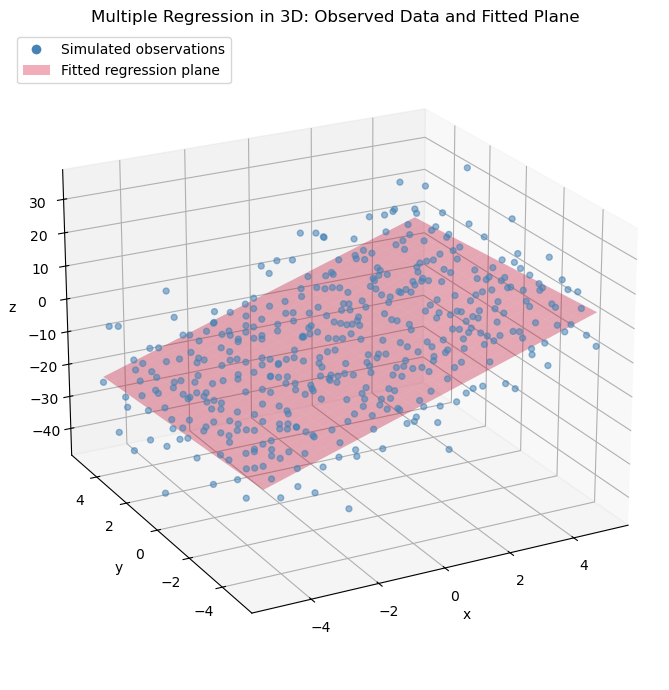

In [32]:
reg3d_Z_hat_grid = (
    reg3d_ols_model.params['Intercept']
    + reg3d_ols_model.params['x'] * reg3d_X_grid
    + reg3d_ols_model.params['y'] * reg3d_Y_grid
)

fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(projection='3d')
ax.scatter(
    reg3d_data['x'],
    reg3d_data['y'],
    reg3d_data['z'],
    color='steelblue',
    alpha=0.55,
    s=18,
    depthshade=True,
)
ax.plot_surface(
    reg3d_X_grid,
    reg3d_Y_grid,
    reg3d_Z_hat_grid,
    color='crimson',
    alpha=0.35,
    rstride=1,
    cstride=1,
    edgecolor='none',
)
ax.view_init(elev=22, azim=-118)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
ax.set_title('Multiple Regression in 3D: Observed Data and Fitted Plane')
ax.legend(
    handles=[
        Line2D(
            [0],
            [0],
            marker='o',
            color='w',
            markerfacecolor='steelblue',
            markersize=8,
            label='Simulated observations',
        ),
        Patch(facecolor='crimson', alpha=0.35, label='Fitted regression plane'),
    ],
    loc='upper left',
)
plt.tight_layout()
plt.show()

## Iris flower measurements

The classic Iris dataset records four numerical flower measurements and the species label for each specimen. We load `iris.csv` once and inspect its structure before visualizing how the measurements relate to one another across species.

In [33]:
iris = pd.read_csv('iris.csv')

print('Shape (rows, columns):', iris.shape)
print('\nColumn names:', list(iris.columns))
print('\nData types:')
print(iris.dtypes)
print('\nMissing values per column:')
print(iris.isna().sum())
print('\nFirst rows:')
display(iris.head(8))


Shape (rows, columns): (150, 5)

Column names: ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'name']

Data types:
sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
name             object
dtype: object

Missing values per column:
sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
name            0
dtype: int64

First rows:


,sepal_length,sepal_width,petal_length,petal_width,name
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
5,5.4,3.9,1.7,0.4,setosa
6,4.6,3.4,1.4,0.3,setosa
7,5.0,3.4,1.5,0.2,setosa


### Variable descriptions

- **sepal_length** — length of the sepal in centimeters
- **sepal_width** — width of the sepal in centimeters
- **petal_length** — length of the petal in centimeters
- **petal_width** — width of the petal in centimeters
- **name** — iris species (`setosa`, `versicolor`, or `virginica`)


### Scatter matrix of numerical measurements by species

The figure below shows pairwise relationships among the four numerical flower measurements. Points are colored by species so the three iris types can be compared across every pair of variables.

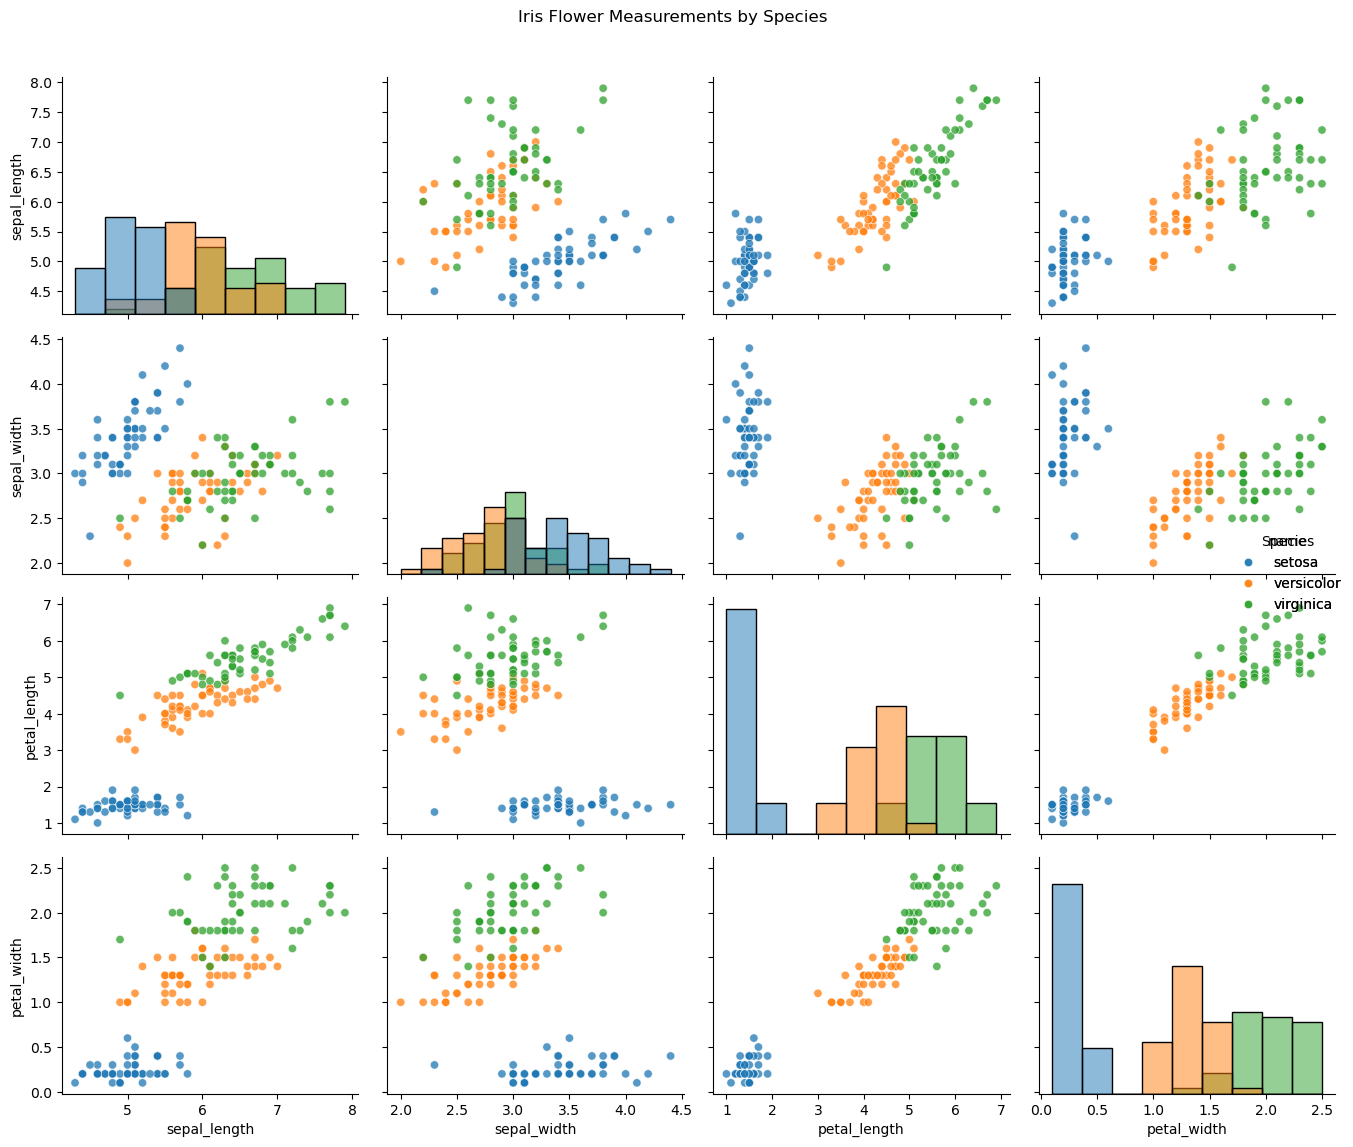

In [34]:
iris_measurements = [
    'sepal_length',
    'sepal_width',
    'petal_length',
    'petal_width',
]

iris_pairplot = sns.pairplot(
    iris,
    vars=iris_measurements,
    hue='name',
    diag_kind='hist',
    plot_kws={'alpha': 0.75},
    height=2.8,
)
iris_pairplot.fig.suptitle(
    'Iris Flower Measurements by Species',
    y=1.02,
)
iris_pairplot.add_legend(title='Species')
plt.tight_layout()
plt.show()


## Is iris species associated with sepal width after accounting for petal length?

Sepal width may differ among species, but petal length also varies by species and may relate to sepal width. We fit a multiple linear regression with sepal width as the outcome and species (categorical) plus petal length as predictors to estimate species differences while holding petal length constant.

In [35]:
iris_sepal_model = smf.ols('sepal_width ~ C(name) + petal_length', data=iris).fit()
print(iris_sepal_model.summary())

versicolor_coef = 'C(name)[T.versicolor]'
virginica_coef = 'C(name)[T.virginica]'

print(
    '\nReference species: setosa (the first level in alphabetical order). '
    'Each species coefficient is the estimated difference in mean sepal width relative '
    'to setosa, holding petal length constant.'
)
print(
    f'Versicolor vs setosa: {iris_sepal_model.params[versicolor_coef]:.4f} '
    f'(p = {iris_sepal_model.pvalues[versicolor_coef]:.4f})'
)
print(
    f'Virginica vs setosa: {iris_sepal_model.params[virginica_coef]:.4f} '
    f'(p = {iris_sepal_model.pvalues[virginica_coef]:.4f})'
)
print(
    f'Petal length: {iris_sepal_model.params["petal_length"]:.4f} '
    f'(p = {iris_sepal_model.pvalues["petal_length"]:.4f}) — change in sepal width '
    f'per one-centimeter increase in petal length, holding species constant.'
)
print(
    f'\nR-squared: {iris_sepal_model.rsquared:.4f} — about '
    f'{100 * iris_sepal_model.rsquared:.1f}% of sepal-width variance is explained by '
    f'species and petal length together in this sample.'
)


                            OLS Regression Results                            
Dep. Variable:            sepal_width   R-squared:                       0.478
Model:                            OLS   Adj. R-squared:                  0.468
Method:                 Least Squares   F-statistic:                     44.63
Date:                Mon, 27 Jul 2026   Prob (F-statistic):           1.58e-20
Time:                        21:50:39   Log-Likelihood:                -38.185
No. Observations:                 150   AIC:                             84.37
Df Residuals:                     146   BIC:                             96.41
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept                 2.98

### F-test: versicolor vs. virginica species coefficients

We test whether the adjusted mean sepal-width difference for versicolor equals that for virginica:

- **Null hypothesis (H₀):** The versicolor and virginica species coefficients are equal (no difference in mean sepal width between versicolor and virginica after accounting for petal length).
- **Alternative hypothesis (H₁):** The two species coefficients differ.

In [36]:
species_f_test = iris_sepal_model.f_test(
    f'{versicolor_coef} = {virginica_coef}'
)
print(species_f_test)

f_stat = float(species_f_test.fvalue)
f_pvalue = float(species_f_test.pvalue)
alpha = 0.05

if f_pvalue < alpha:
    significance = (
        f'The p-value ({f_pvalue:.4f}) is below {alpha}, so we reject H₀ at the 0.05 level. '
        f'The difference between the versicolor and virginica coefficients is statistically significant.'
    )
else:
    significance = (
        f'The p-value ({f_pvalue:.4f}) is not below {alpha}, so we do not reject H₀ at the 0.05 level. '
        f'There is not statistically significant evidence that versicolor and virginica differ in '
        f'adjusted mean sepal width.'
    )

print(f'\nF statistic: {f_stat:.4f}')
print(f'p-value: {f_pvalue:.4f}')
print(f'\n{significance}')


<F test: F=3.2453353465743553, p=0.07369058781700252, df_denom=146, df_num=1>

F statistic: 3.2453
p-value: 0.0737

The p-value (0.0737) is not below 0.05, so we do not reject H₀ at the 0.05 level. There is not statistically significant evidence that versicolor and virginica differ in adjusted mean sepal width.


## 1985 Current Population Survey wages data

The `wages.txt` file combines a descriptive header, whitespace-separated numeric records, and a short footer with contact information. We inspect the raw file structure first so the data rows can be read correctly without replacing the file.

In [37]:
# wages.txt has a 27-line header, 534 whitespace-separated data rows, and a footer.
with open('wages.txt') as wages_file:
    wages_lines = wages_file.readlines()

print(f'Total lines in wages.txt: {len(wages_lines)}')
print('First header line:', wages_lines[0].rstrip())
print('First data line:', wages_lines[27].rstrip())
print(
    '\nReading strategy: skip the first 27 header lines, read 534 numeric rows, '
    'and ignore the footer contact block.'
)


Total lines in wages.txt: 567
First header line: Determinants of Wages from the 1985 Current Population Survey
First data line: 8	0	1	21	0	5.1	35	2	6	1	1

Reading strategy: skip the first 27 header lines, read 534 numeric rows, and ignore the footer contact block.


In [38]:
WAGES_COLUMN_NAMES = [
    'education',
    'south',
    'sex',
    'experience',
    'union',
    'wage',
    'age',
    'race',
    'occupation',
    'sector',
    'marital_status',
]
WAGES_NROWS = 534

wages = pd.read_csv(
    'wages.txt',
    sep=r'\s+',
    header=None,
    names=WAGES_COLUMN_NAMES,
    skiprows=27,
    nrows=WAGES_NROWS,
)

print('Shape (rows, columns):', wages.shape)
print('\nData types:')
print(wages.dtypes)
print('\nMissing values per column:')
print(wages.isna().sum())
print('\nFirst rows:')
display(wages.head(8))


Shape (rows, columns): (534, 11)

Data types:
education           int64
south               int64
sex                 int64
experience          int64
union               int64
wage              float64
age                 int64
race                int64
occupation          int64
sector              int64
marital_status      int64
dtype: object

Missing values per column:
education         0
south             0
sex               0
experience        0
union             0
wage              0
age               0
race              0
occupation        0
sector            0
marital_status    0
dtype: int64

First rows:


,education,south,sex,experience,union,wage,age,race,occupation,sector,marital_status
0,8,0,1,21,0,5.10,35,2,6,1,1
1,9,0,1,42,0,4.95,57,3,6,1,1
2,12,0,0,1,0,6.67,19,3,6,1,0
3,12,0,0,4,0,4.00,22,3,6,0,0
4,12,0,0,17,0,7.50,35,3,6,0,1
5,13,0,0,9,1,13.07,28,3,6,0,0
6,10,1,0,27,0,4.45,43,3,6,0,0
7,12,0,0,9,0,19.47,27,3,6,0,0


### Data dictionary

| Variable | Description |
| --- | --- |
| **education** | Years of education |
| **south** | Geographic region indicator (1 = lives in South, 0 = elsewhere) |
| **sex** | Sex indicator before relabeling (1 = female, 0 = male) |
| **experience** | Years of work experience |
| **union** | Union membership (1 = member, 0 = not a member) |
| **wage** | Hourly wage in dollars |
| **age** | Age in years |
| **race** | Race code (1 = other, 2 = Hispanic, 3 = white) |
| **occupation** | Occupation category (1 = management, 2 = sales, 3 = clerical, 4 = service, 5 = professional, 6 = other) |
| **sector** | Employment sector (0 = other, 1 = manufacturing, 2 = construction) |
| **marital_status** | Marital status (0 = unmarried, 1 = married) |

In [39]:
wages['sex'] = wages['sex'].map({0: 'Male', 1: 'Female'})
wages['log10_wage'] = np.log10(wages['wage'])

print('Sex categories:', wages['sex'].unique().tolist())
print('\nSample of original wage and log10 wage:')
display(wages[['wage', 'log10_wage', 'sex', 'education', 'experience']].head(8))


Sex categories: ['Female', 'Male']

Sample of original wage and log10 wage:


,wage,log10_wage,sex,education,experience
0,5.10,0.707570,Female,8,21
1,4.95,0.694605,Female,9,42
2,6.67,0.824126,Male,12,1
3,4.00,0.602060,Male,12,4
4,7.50,0.875061,Male,12,17
5,13.07,1.116276,Male,13,9
6,4.45,0.648360,Male,10,27
7,19.47,1.289366,Male,12,9


### Why use a logarithmic wage transformation?

Hourly wages are positive and often right-skewed, with variability that tends to increase at higher wage levels. A base-10 log transform compresses large values, makes the distribution more symmetric, and stabilizes variance. On the log scale, multiplicative wage differences (for example, a percentage gap between groups) become additive, which aligns with standard linear regression assumptions. The original dollar wage is kept in `wage`; `log10_wage` is added for later modeling.

## Visualizing log wage, age, and education

We examine how base-10 log wage, age, and education relate to one another in the prepared `wages` DataFrame. Pairplots show every pairwise combination with regression trends; additional views color points by sex, race, and union membership.

In [40]:
wage_plot_vars = ['log10_wage', 'age', 'education']

wages['race_label'] = wages['race'].map(
    {1: 'Other', 2: 'Hispanic', 3: 'White'}
)
wages['union_label'] = wages['union'].map(
    {0: 'Non-union', 1: 'Union member'}
)


### Pairplot without grouping

The first figure shows all workers together, with regression lines on the off-diagonal panels to summarize linear trends among log wage, age, and education.

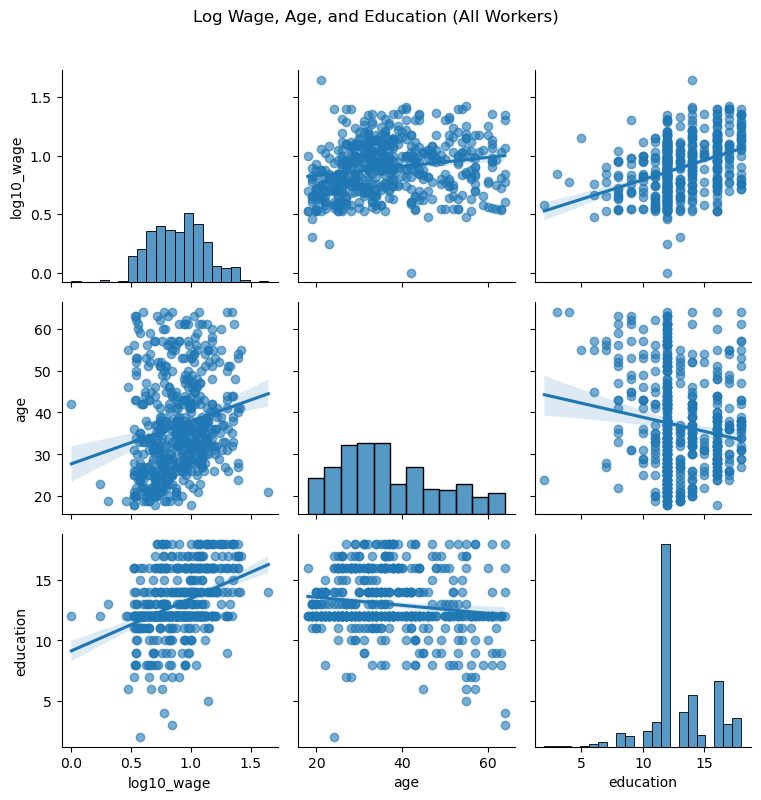

In [41]:
wage_pairplot_all = sns.pairplot(
    wages,
    vars=wage_plot_vars,
    kind='reg',
    plot_kws={'scatter_kws': {'alpha': 0.6}},
    height=2.6,
)
wage_pairplot_all.fig.suptitle(
    'Log Wage, Age, and Education (All Workers)',
    y=1.02,
)
plt.tight_layout()
plt.show()


### Pairplot by sex

Points are colored by sex (`Male` or `Female`) to compare how the three variables relate within each sex group.

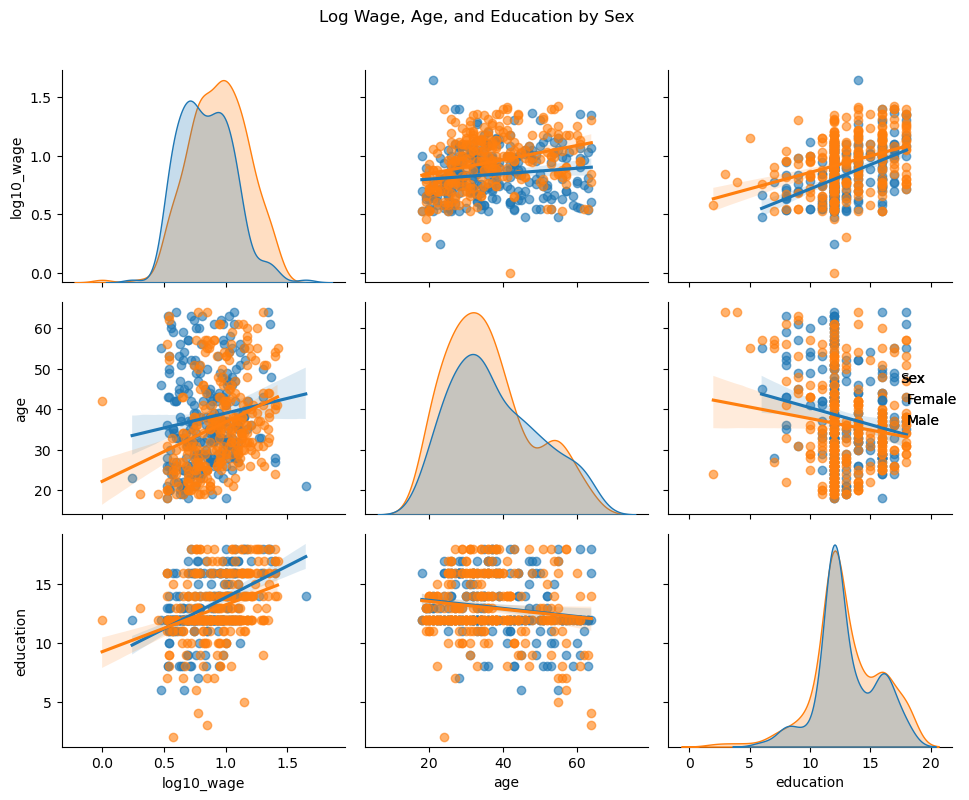

In [42]:
wage_pairplot_sex = sns.pairplot(
    wages,
    vars=wage_plot_vars,
    hue='sex',
    kind='reg',
    plot_kws={'scatter_kws': {'alpha': 0.6}},
    height=2.6,
)
wage_pairplot_sex.fig.suptitle(
    'Log Wage, Age, and Education by Sex',
    y=1.02,
)
wage_pairplot_sex.add_legend(title='Sex')
plt.tight_layout()
plt.show()


### Pairplot by race

Points are colored by race label: **Other**, **Hispanic**, or **White** (coded 1, 2, and 3 in the original file).

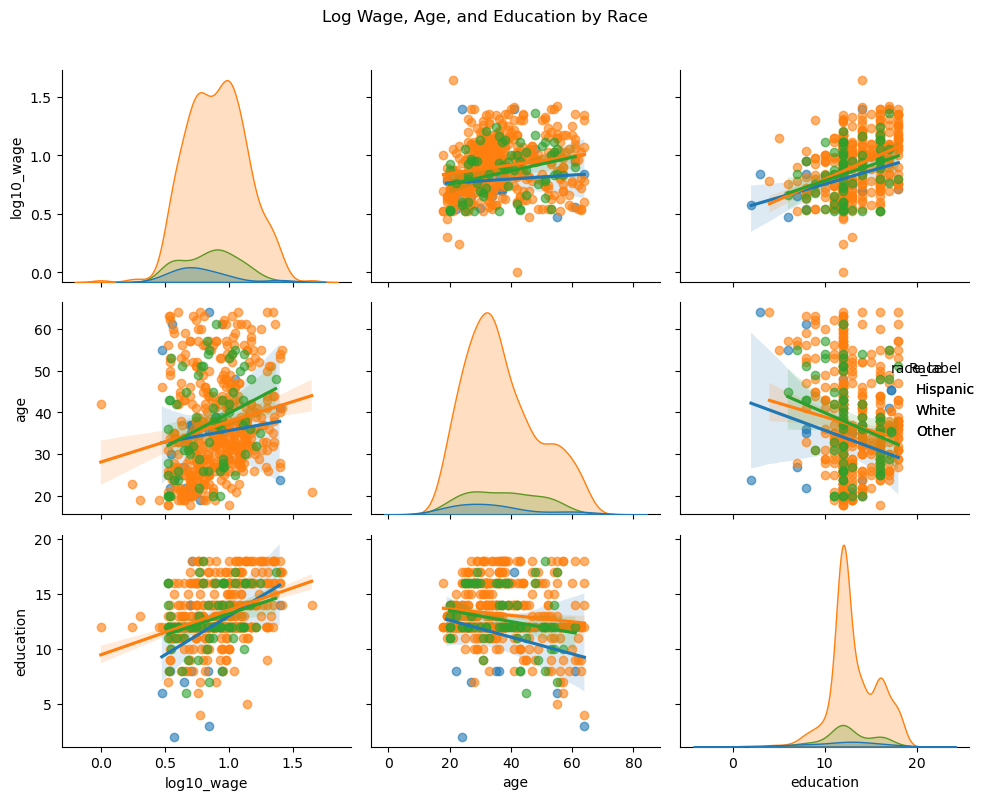

In [43]:
wage_pairplot_race = sns.pairplot(
    wages,
    vars=wage_plot_vars,
    hue='race_label',
    kind='reg',
    plot_kws={'scatter_kws': {'alpha': 0.6}},
    height=2.6,
)
wage_pairplot_race.fig.suptitle(
    'Log Wage, Age, and Education by Race',
    y=1.02,
)
wage_pairplot_race.add_legend(title='Race')
plt.tight_layout()
plt.show()


### Pairplot by union membership

Points are colored by union status: **Non-union** (0) or **Union member** (1).

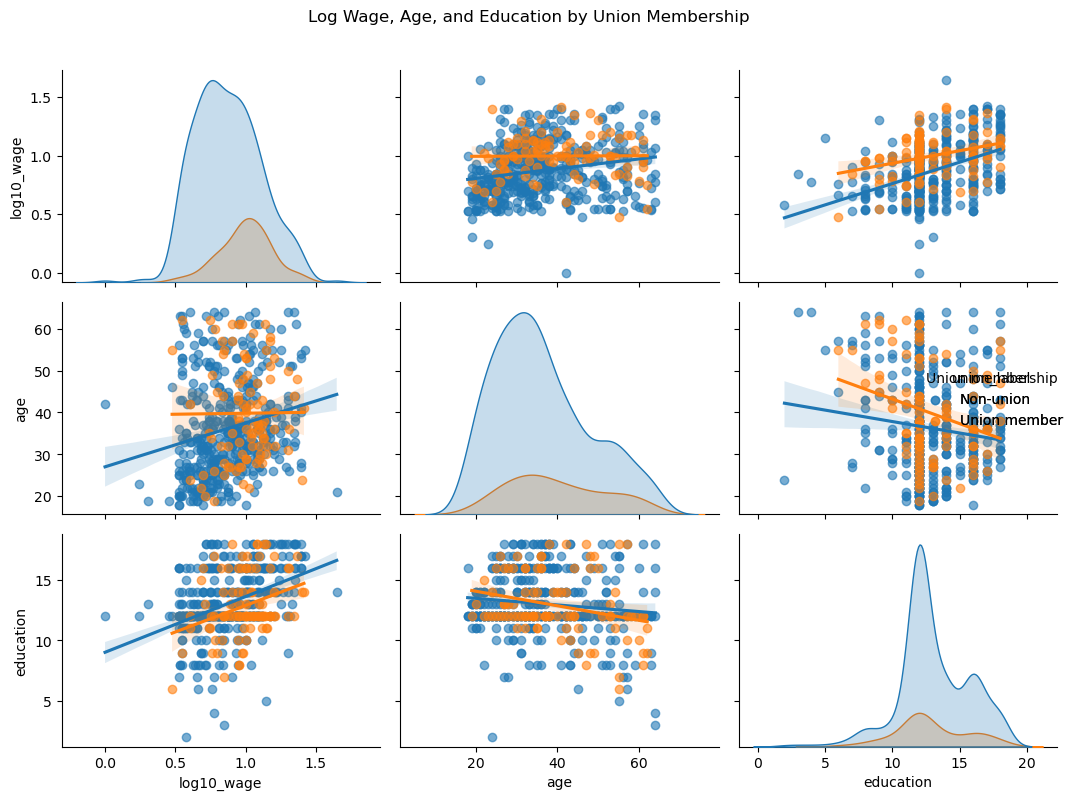

In [44]:
wage_pairplot_union = sns.pairplot(
    wages,
    vars=wage_plot_vars,
    hue='union_label',
    kind='reg',
    plot_kws={'scatter_kws': {'alpha': 0.6}},
    height=2.6,
)
wage_pairplot_union.fig.suptitle(
    'Log Wage, Age, and Education by Union Membership',
    y=1.02,
)
wage_pairplot_union.add_legend(title='Union membership')
plt.tight_layout()
plt.show()


### Log wage versus education

A separate regression plot focuses on the relationship between education and log wage across all workers.

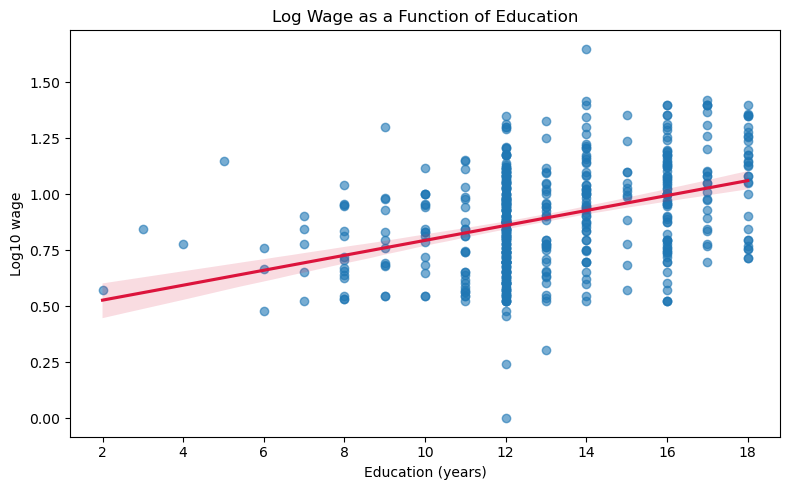

In [45]:
plt.figure(figsize=(8, 5))
sns.regplot(
    data=wages,
    x='education',
    y='log10_wage',
    scatter_kws={'alpha': 0.6},
    line_kws={'color': 'crimson'},
)
plt.xlabel('Education (years)')
plt.ylabel('Log10 wage')
plt.title('Log Wage as a Function of Education')
plt.tight_layout()
plt.show()


## Does the education–log wage relationship differ between male and female participants?

We ask whether years of education relate to log wage differently for male and female workers. First we fit an additive model with education and gender; then we add an education × gender interaction to test whether the education slope differs by sex.

In [46]:
wage_additive_model = smf.ols('log10_wage ~ education + C(sex)', data=wages).fit()
print(wage_additive_model.summary())

male_coef = 'C(sex)[T.Male]'
print(
    f"\nEducation: each additional year of education is associated with a "
    f"{wage_additive_model.params['education']:.4f}-unit change in log10 wage, "
    f"holding sex constant (p = {wage_additive_model.pvalues['education']:.4f})."
)
print(
    f"Gender (Male vs Female): male workers have an estimated "
    f"{wage_additive_model.params[male_coef]:.4f} difference in log10 wage, "
    f"holding education constant (p = {wage_additive_model.pvalues[male_coef]:.4f})."
)


                            OLS Regression Results                            
Dep. Variable:             log10_wage   R-squared:                       0.193
Model:                            OLS   Adj. R-squared:                  0.190
Method:                 Least Squares   F-statistic:                     63.42
Date:                Mon, 27 Jul 2026   Prob (F-statistic):           2.01e-25
Time:                        21:50:48   Log-Likelihood:                 86.654
No. Observations:                 534   AIC:                            -167.3
Df Residuals:                     531   BIC:                            -154.5
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept          0.4053      0.046      8.

In [47]:
wage_interaction_model = smf.ols('log10_wage ~ education * C(sex)', data=wages).fit()
print(wage_interaction_model.summary())

interaction_coef = 'education:C(sex)[T.Male]'
interaction_p = wage_interaction_model.pvalues[interaction_coef]

print(
    '\nReference group: Female. The intercept is the estimated log10 wage for female '
    f"workers when education = 0 ({wage_interaction_model.params['Intercept']:.4f})."
)
print(
    f"Gender effect (Male vs Female at education = 0): "
    f"{wage_interaction_model.params[male_coef]:.4f} "
    f"(p = {wage_interaction_model.pvalues[male_coef]:.4f})."
)
print(
    f"Education slope for females: {wage_interaction_model.params['education']:.4f} "
    f"(p = {wage_interaction_model.pvalues['education']:.4f})."
)
print(
    f"Interaction (additional education slope for males): "
    f"{wage_interaction_model.params[interaction_coef]:.4f} "
    f"(p = {interaction_p:.4f})."
)

alpha = 0.05
if interaction_p < alpha:
    interaction_conclusion = (
        f'The interaction p-value ({interaction_p:.4f}) is below {alpha}, so the data '
        'support the claim that education benefits one gender more than the other.'
    )
else:
    interaction_conclusion = (
        f'The interaction p-value ({interaction_p:.4f}) is not below {alpha}, so the data '
        'do not provide statistically significant evidence that education benefits one '
        'gender more than the other.'
    )
print(f'\n{interaction_conclusion}')


                            OLS Regression Results                            
Dep. Variable:             log10_wage   R-squared:                       0.198
Model:                            OLS   Adj. R-squared:                  0.194
Method:                 Least Squares   F-statistic:                     43.72
Date:                Mon, 27 Jul 2026   Prob (F-statistic):           2.94e-25
Time:                        21:50:48   Log-Likelihood:                 88.503
No. Observations:                 534   AIC:                            -169.0
Df Residuals:                     530   BIC:                            -151.9
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept               

### Education–log wage trends by gender

The earlier single regression plot did not show separate fitted lines by sex. The figure below overlays gender-specific education trends from the interaction model.

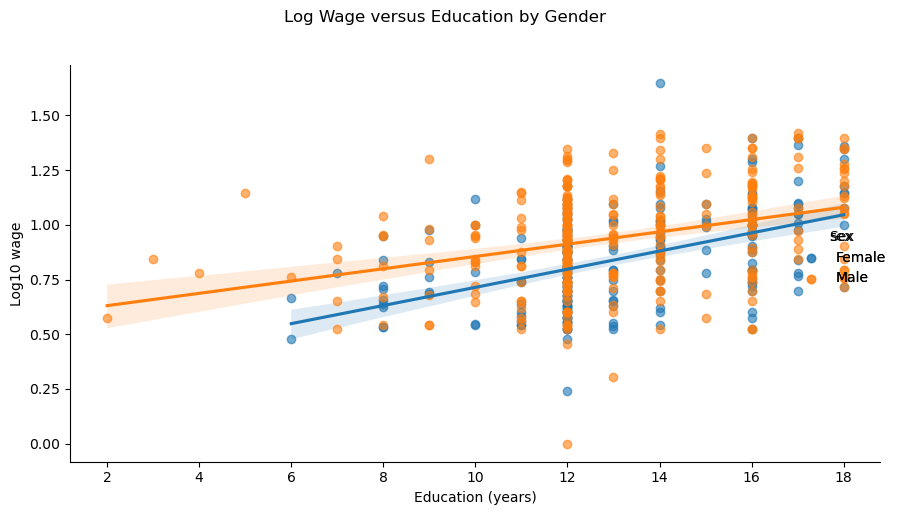

In [48]:
wage_gender_lmplot = sns.lmplot(
    data=wages,
    x='education',
    y='log10_wage',
    hue='sex',
    height=5,
    aspect=1.4,
    scatter_kws={'alpha': 0.6},
)
wage_gender_lmplot.fig.suptitle(
    'Log Wage versus Education by Gender',
    y=1.02,
)
wage_gender_lmplot.set_axis_labels('Education (years)', 'Log10 wage')
wage_gender_lmplot.add_legend(title='Sex')
plt.tight_layout()
plt.show()


## Air fares before and after 9/11

The `airfares.txt` file lists airline routes with city populations, route distance, average fares, and passenger counts for 2000 and 2001. The file has no header row; fields are separated by variable whitespace.

The local input file contains **4,177 actual data rows** and no header row. Reading it with `header=None` preserves all routes. If the first row were treated as a header instead, the resulting table would have **4,176 rows** and slightly different numerical results. We do **not** drop the first observation merely to reproduce that website row count.

This notebook explicitly calculates route-level fare changes as **2001 minus 2000**. That definition is stated directly in the analysis rather than assumed from an external source, so some numerical results may differ from values shown on the website walkthrough.


In [49]:
# airfares.txt has no header row; fields are separated by variable whitespace.
with open('airfares.txt') as airfares_file:
    airfares_preview = airfares_file.readlines()[:3]

print('First 3 lines of airfares.txt:')
for line_number, line in enumerate(airfares_preview, start=1):
    print(f'{line_number}: {line.rstrip()}')
print(
    '\nEach line contains nine fields: origin, destination, two city populations, '
    'distance, 2000 fare, 2000 passengers, 2001 fare, and 2001 passengers.'
)


First 3 lines of airfares.txt:
1: ABE   ATL     613.84   3627.18   692  215.77    102.17  188.12     87.06
2: ABE   BNA     613.84   1134.52   685  272.26     24.45  284.89     20.86
3: ABE   CLE     613.84   2908.44   339  322.20     23.36  326.70     18.58

Each line contains nine fields: origin, destination, two city populations, distance, 2000 fare, 2000 passengers, 2001 fare, and 2001 passengers.


In [50]:
AIRFARES_COLUMN_NAMES = [
    'origin',
    'destination',
    'pop_origin',
    'pop_destination',
    'distance',
    'fare_2000',
    'passengers_2000',
    'fare_2001',
    'passengers_2001',
]

# Keep all 4,177 data rows; do not treat the first row as a header or drop it.
airfares = pd.read_csv(
    'airfares.txt',
    sep=r'\s+',
    header=None,
    names=AIRFARES_COLUMN_NAMES,
)
airfares = airfares.copy()

print('Shape (rows, columns):', airfares.shape)
print('\nData types:')
print(airfares.dtypes)
print('\nMissing values per column:')
print(airfares.isna().sum())
print('\nFirst rows:')
display(airfares.head(8))


Shape (rows, columns): (4177, 9)

Data types:
origin              object
destination         object
pop_origin         float64
pop_destination    float64
distance             int64
fare_2000          float64
passengers_2000    float64
fare_2001          float64
passengers_2001    float64
dtype: object

Missing values per column:
origin             0
destination        0
pop_origin         0
pop_destination    0
distance           0
fare_2000          0
passengers_2000    0
fare_2001          0
passengers_2001    0
dtype: int64

First rows:


,origin,destination,pop_origin,pop_destination,distance,fare_2000,passengers_2000,fare_2001,passengers_2001
0,ABE,ATL,613.84,3627.18,692,215.77,102.17,188.12,87.06
1,ABE,BNA,613.84,1134.52,685,272.26,24.45,284.89,20.86
2,ABE,CLE,613.84,2908.44,339,322.20,23.36,326.70,18.58
3,ABE,CLT,613.84,1350.24,480,250.27,52.60,241.53,35.76
4,ABE,CMH,613.84,1460.24,395,259.29,19.23,240.71,14.23
5,ABE,DEN,613.84,2318.36,1539,202.77,80.97,209.82,55.10
6,ABE,DFW,613.84,4683.01,1308,344.47,45.54,293.50,40.21
7,ABE,DTW,613.84,5438.76,424,191.70,93.26,248.21,75.54


In [51]:
airfares['log10_passengers_2000'] = np.log10(airfares['passengers_2000'])
airfares['log10_passengers_2001'] = np.log10(airfares['passengers_2001'])

print('Original and log10 passenger counts (first rows):')
display(
    airfares[
        [
            'origin',
            'destination',
            'passengers_2000',
            'log10_passengers_2000',
            'passengers_2001',
            'log10_passengers_2001',
        ]
    ].head(8)
)


Original and log10 passenger counts (first rows):


,origin,destination,passengers_2000,log10_passengers_2000,passengers_2001,log10_passengers_2001
0,ABE,ATL,102.17,2.009323,87.06,1.939819
1,ABE,BNA,24.45,1.388279,20.86,1.319314
2,ABE,CLE,23.36,1.368473,18.58,1.269046
3,ABE,CLT,52.60,1.720986,35.76,1.553398
4,ABE,CMH,19.23,1.283979,14.23,1.153205
5,ABE,DEN,80.97,1.908324,55.10,1.741152
6,ABE,DFW,45.54,1.658393,40.21,1.604334
7,ABE,DTW,93.26,1.969695,75.54,1.878177


### Long-format air fares by route and year

For year-specific analyses, the wide table is reshaped so each route contributes one row per year with shared route information, distance, fare, and log passenger count.

In [52]:
route_id_cols = [
    'origin',
    'destination',
    'pop_origin',
    'pop_destination',
    'distance',
]

airfares_2000 = airfares.loc[:, route_id_cols].copy()
airfares_2000.loc[:, 'year'] = 2000
airfares_2000.loc[:, 'fare'] = airfares['fare_2000'].to_numpy()
airfares_2000.loc[:, 'passengers'] = airfares['passengers_2000'].to_numpy()
airfares_2000.loc[:, 'log10_passengers'] = airfares['log10_passengers_2000'].to_numpy()

airfares_2001 = airfares.loc[:, route_id_cols].copy()
airfares_2001.loc[:, 'year'] = 2001
airfares_2001.loc[:, 'fare'] = airfares['fare_2001'].to_numpy()
airfares_2001.loc[:, 'passengers'] = airfares['passengers_2001'].to_numpy()
airfares_2001.loc[:, 'log10_passengers'] = airfares['log10_passengers_2001'].to_numpy()

airfares_long = pd.concat([airfares_2000, airfares_2001], ignore_index=True)

print('Long-format shape (rows, columns):', airfares_long.shape)
print('\nFirst rows:')
display(airfares_long.head(8))


Long-format shape (rows, columns): (8354, 9)

First rows:


,origin,destination,pop_origin,pop_destination,distance,year,fare,passengers,log10_passengers
0,ABE,ATL,613.84,3627.18,692,2000,215.77,102.17,2.009323
1,ABE,BNA,613.84,1134.52,685,2000,272.26,24.45,1.388279
2,ABE,CLE,613.84,2908.44,339,2000,322.20,23.36,1.368473
3,ABE,CLT,613.84,1350.24,480,2000,250.27,52.60,1.720986
4,ABE,CMH,613.84,1460.24,395,2000,259.29,19.23,1.283979
5,ABE,DEN,613.84,2318.36,1539,2000,202.77,80.97,1.908324
6,ABE,DFW,613.84,4683.01,1308,2000,344.47,45.54,1.658393
7,ABE,DTW,613.84,5438.76,424,2000,191.70,93.26,1.969695


## Visualizing fare, distance, and log passenger count

We examine how route fare, distance, and log passenger count relate to one another using the prepared wide and long airfare DataFrames.

### Pairplot across all route-year observations

The first figure pools every route-year row from `airfares_long` without distinguishing 2000 from 2001, showing regression trends among fare, distance, and log passenger count.

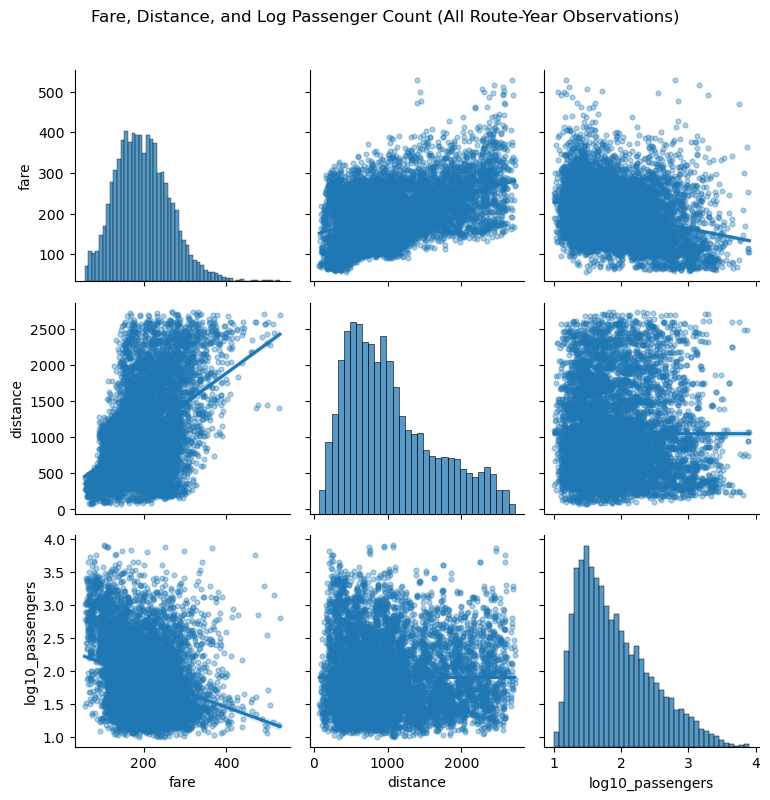

In [53]:
airfare_plot_vars = ['fare', 'distance', 'log10_passengers']

airfare_pairplot_all = sns.pairplot(
    airfares_long,
    vars=airfare_plot_vars,
    kind='reg',
    plot_kws={'scatter_kws': {'alpha': 0.35, 's': 12}},
    height=2.6,
)
airfare_pairplot_all.fig.suptitle(
    'Fare, Distance, and Log Passenger Count (All Route-Year Observations)',
    y=1.02,
)
plt.tight_layout()
plt.show()


### Pairplot by year

The second figure uses the same three variables from `airfares_long` but colors points by year so 2000 and 2001 can be compared directly.

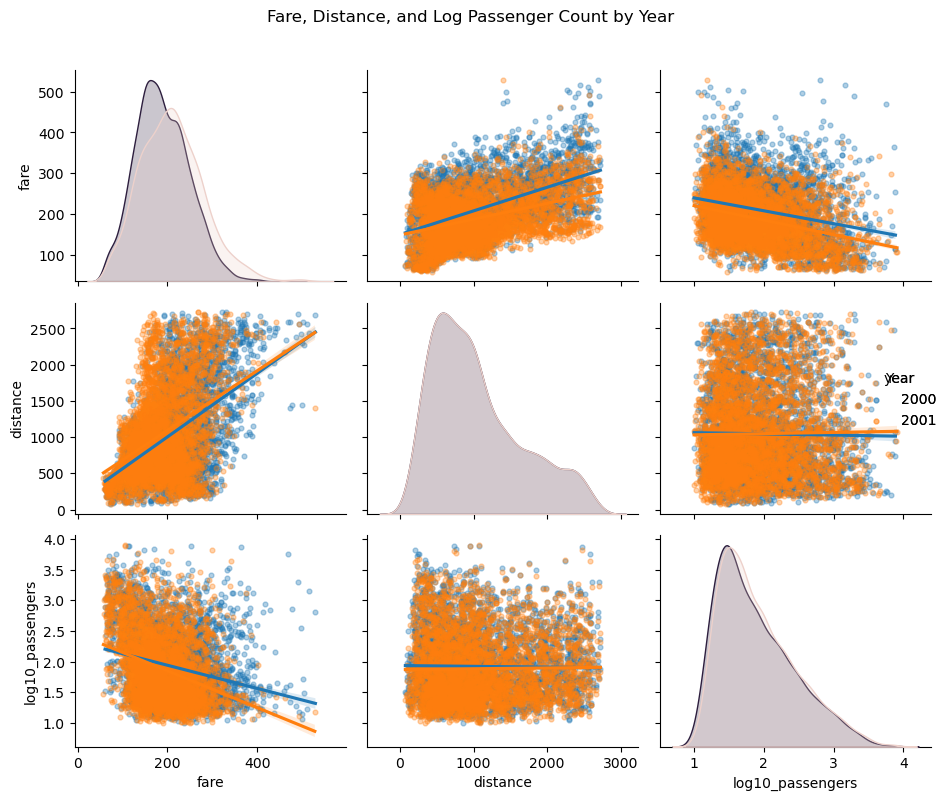

In [54]:
airfare_pairplot_year = sns.pairplot(
    airfares_long,
    vars=airfare_plot_vars,
    hue='year',
    kind='reg',
    plot_kws={'scatter_kws': {'alpha': 0.35, 's': 12}},
    height=2.6,
)
airfare_pairplot_year.fig.suptitle(
    'Fare, Distance, and Log Passenger Count by Year',
    y=1.02,
)
airfare_pairplot_year.add_legend(title='Year')
plt.tight_layout()
plt.show()


### Route-level changes from 2000 to 2001

For each route in the wide `airfares` table, we compute differences as **2001 − 2000** for fare and log passenger count. Negative values therefore indicate a decrease from 2000 to 2001. The boxplots summarize the distribution of these route-level changes.

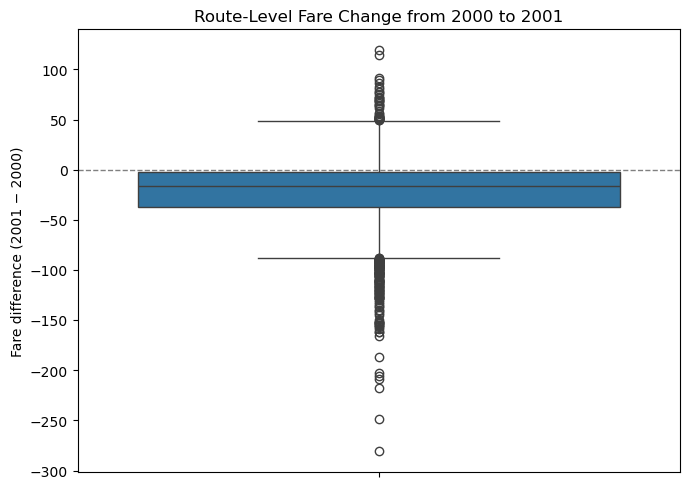

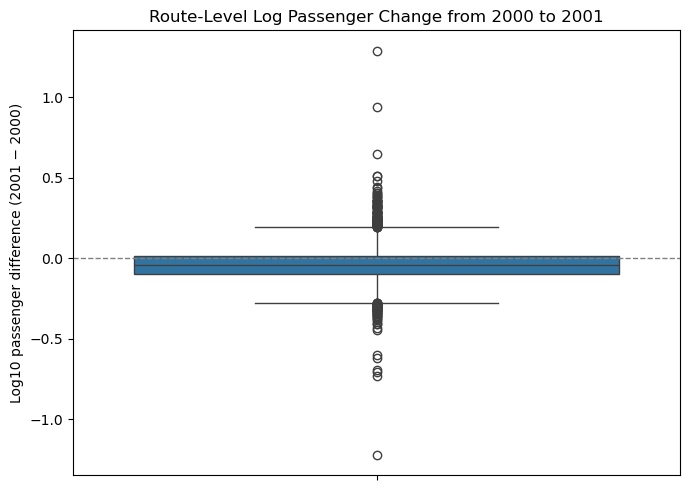

In [55]:
airfares['fare_diff_2001_2000'] = airfares['fare_2001'] - airfares['fare_2000']
airfares['log10_passengers_diff_2001_2000'] = (
    airfares['log10_passengers_2001'] - airfares['log10_passengers_2000']
)

plt.figure(figsize=(7, 5))
sns.boxplot(y=airfares['fare_diff_2001_2000'])
plt.axhline(0, color='gray', linestyle='--', linewidth=1)
plt.ylabel('Fare difference (2001 − 2000)')
plt.title('Route-Level Fare Change from 2000 to 2001')
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 5))
sns.boxplot(y=airfares['log10_passengers_diff_2001_2000'])
plt.axhline(0, color='gray', linestyle='--', linewidth=1)
plt.ylabel('Log10 passenger difference (2001 − 2000)')
plt.title('Route-Level Log Passenger Change from 2000 to 2001')
plt.tight_layout()
plt.show()


## Statistical modeling of air fares

We model fare using the long-format route-year data, compare ordinary least squares with a robust alternative, and then examine how the 2001 − 2000 fare change relates to route distance at the route level.

### Ordinary least-squares model: fare ~ distance + log passenger count

The first model uses `airfares_long` and treats distance and log10 passenger count as linear predictors of fare across all route-year observations.

In [56]:
fare_ols_model = smf.ols(
    'fare ~ distance + log10_passengers',
    data=airfares_long,
).fit()
print(fare_ols_model.summary())

print(
    f"\nIntercept: {fare_ols_model.params['Intercept']:.4f} "
    f"(p = {fare_ols_model.pvalues['Intercept']:.4f}) — estimated fare when distance "
    f"and log10 passenger count are zero (not a realistic route, but the regression baseline)."
)
print(
    f"Distance: {fare_ols_model.params['distance']:.6f} "
    f"(p = {fare_ols_model.pvalues['distance']:.4f}) — change in fare per one-unit "
    f"increase in distance, holding log passenger count constant."
)
print(
    f"Log10 passengers: {fare_ols_model.params['log10_passengers']:.4f} "
    f"(p = {fare_ols_model.pvalues['log10_passengers']:.4f}) — change in fare per "
    f"one-unit increase in log10 passenger count, holding distance constant."
)
print(
    f"\nR-squared: {fare_ols_model.rsquared:.4f} — about "
    f"{100 * fare_ols_model.rsquared:.1f}% of fare variance is explained by distance and "
    f"log passenger count in this pooled sample."
)


                            OLS Regression Results                            
Dep. Variable:                   fare   R-squared:                       0.275
Model:                            OLS   Adj. R-squared:                  0.275
Method:                 Least Squares   F-statistic:                     1585.
Date:                Mon, 27 Jul 2026   Prob (F-statistic):               0.00
Time:                        21:50:57   Log-Likelihood:                -45542.
No. Observations:                8354   AIC:                         9.109e+04
Df Residuals:                    8351   BIC:                         9.111e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept          211.2501      2.466  

### Robust linear model with the same predictors

A robust linear model (RLM) down-weights extreme observations rather than treating every point equally. We fit the same specification and compare coefficient directions and approximate sizes with OLS, without assuming either method is automatically correct.

In [57]:
fare_rlm_model = smf.rlm(
    'fare ~ distance + log10_passengers',
    data=airfares_long,
).fit()
print(fare_rlm_model.summary())

comparison = pd.DataFrame(
    {
        'OLS': fare_ols_model.params,
        'RLM': fare_rlm_model.params,
    }
)
comparison['Same direction'] = np.sign(comparison['OLS']) == np.sign(comparison['RLM'])
print('\nCoefficient comparison:')
display(comparison.round(4))

print(
    'Both models estimate a positive distance effect and a negative log-passenger effect. '
    'The robust coefficients are similar in direction and roughly comparable in magnitude, '
    'which suggests the OLS pattern is not driven entirely by a handful of outliers. '
    'Neither model is automatically preferred; OLS is efficient under ideal conditions, '
    'whereas RLM may be more stable when extreme fares are present.'
)


                    Robust linear Model Regression Results                    
Dep. Variable:                   fare   No. Observations:                 8354
Model:                            RLM   Df Residuals:                     8351
Method:                          IRLS   Df Model:                            2
Norm:                          HuberT                                         
Scale Est.:                       mad                                         
Cov Type:                          H1                                         
Date:                Mon, 27 Jul 2026                                         
Time:                        21:50:57                                         
No. Iterations:                    13                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept          215.0945      2.448  

,OLS,RLM,Same direction
Intercept,211.2501,215.0945,True
distance,0.0484,0.0460,True
log10_passengers,-32.8908,-35.2675,True


Both models estimate a positive distance effect and a negative log-passenger effect. The robust coefficients are similar in direction and roughly comparable in magnitude, which suggests the OLS pattern is not driven entirely by a handful of outliers. Neither model is automatically preferred; OLS is efficient under ideal conditions, whereas RLM may be more stable when extreme fares are present.


### Route-level model: 2001 − 2000 fare difference ~ distance

Using the wide `airfares` table, we regress the route-level fare change (2001 minus 2000) on distance to describe how fare shifts between years relate to route length.

In [58]:
fare_change_model = smf.ols(
    'fare_diff_2001_2000 ~ distance',
    data=airfares,
).fit()
print(fare_change_model.summary())

intercept_p = fare_change_model.pvalues['Intercept']
distance_p = fare_change_model.pvalues['distance']

print(
    f"\nIntercept: {fare_change_model.params['Intercept']:.4f} "
    f"(p = {intercept_p:.4f}) — estimated average fare change from 2000 to 2001 for "
    f"routes with distance = 0."
)
print(
    f"Distance: {fare_change_model.params['distance']:.6f} "
    f"(p = {distance_p:.4f}) — change in the 2001 − 2000 fare difference per "
    f"one-unit increase in distance."
)

if intercept_p < 0.05:
    intercept_msg = (
        'The intercept is statistically significant, suggesting an overall average fare '
        'shift between 2000 and 2001 after accounting for the distance effect in this model.'
    )
else:
    intercept_msg = (
        'The intercept is not statistically significant at the 0.05 level, so this sample '
        'does not provide strong evidence of a uniform average fare change independent of distance.'
    )

if fare_change_model.params['distance'] < 0:
    slope_msg = (
        'The negative distance coefficient indicates that longer routes tended to experience '
        'more negative (or less positive) fare changes from 2000 to 2001, implying that the '
        'fare–distance relationship shifted between the two years.'
    )
else:
    slope_msg = (
        'The positive distance coefficient indicates that longer routes tended to experience '
        'more positive fare changes from 2000 to 2001, implying a shift in how fare relates to distance.'
    )

print(f'\n{intercept_msg}')
print(slope_msg)


                             OLS Regression Results                            
Dep. Variable:     fare_diff_2001_2000   R-squared:                       0.139
Model:                             OLS   Adj. R-squared:                  0.138
Method:                  Least Squares   F-statistic:                     672.3
Date:                 Mon, 27 Jul 2026   Prob (F-statistic):          1.44e-137
Time:                         21:50:57   Log-Likelihood:                -20040.
No. Observations:                 4177   AIC:                         4.008e+04
Df Residuals:                     4175   BIC:                         4.010e+04
Df Model:                            1                                         
Covariance Type:             nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -1.3051      0.897     -1.45

### Fare change versus distance

The regression plot below shows route-level 2001 − 2000 fare differences against distance with the fitted line from the route-level model.

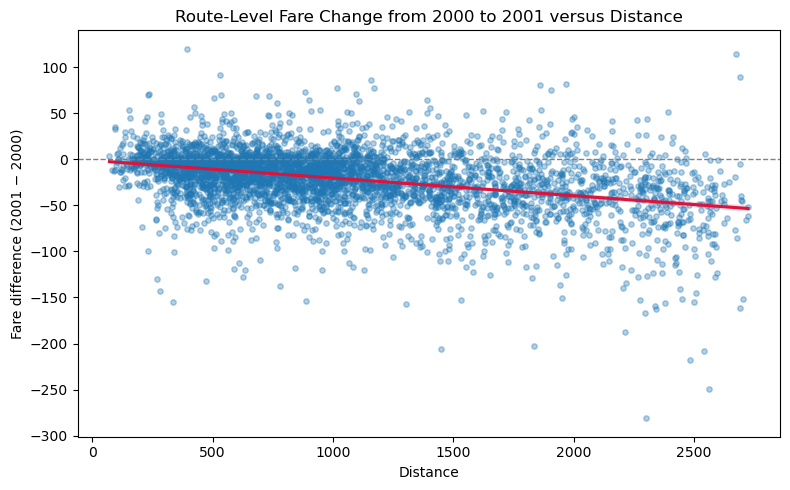

In [59]:
plt.figure(figsize=(8, 5))
sns.regplot(
    data=airfares,
    x='distance',
    y='fare_diff_2001_2000',
    scatter_kws={'alpha': 0.35, 's': 15},
    line_kws={'color': 'crimson'},
)
plt.axhline(0, color='gray', linestyle='--', linewidth=1)
plt.xlabel('Distance')
plt.ylabel('Fare difference (2001 − 2000)')
plt.title('Route-Level Fare Change from 2000 to 2001 versus Distance')
plt.tight_layout()
plt.show()


## Conclusion

**Brain size.** In this small observational sample, descriptive averages differ by gender for several variables, but formal tests for a gender difference in verbal IQ and in the adjusted regression gender coefficient were not statistically significant at the 0.05 level. Paired comparisons of FSIQ and PIQ likewise did not show strong evidence of a mean within-person difference. Multiple regression suggested associations between verbal IQ and both MRI count and height in complete-case participants, while the gender term was not significant after adjustment.

**Three-dimensional regression.** On the simulated grid, both predictors were statistically significant: higher *x* was associated with higher *z* and higher *y* with lower *z*, consistent with the generating model. The fitted plane explained about 59% of the variance in *z*.

**Iris.** After accounting for petal length, species remained associated with sepal width; versicolor and virginica both differed from setosa, and petal length had a positive adjusted association with sepal width. The F-test comparing versicolor and virginica coefficients was not significant at the 0.05 level.

**Wages.** Log wage increased with education in the additive model, and male workers had higher estimated log wages at the reference education level. The education-by-sex interaction was not statistically significant at the 0.05 level, so the data do not provide strong evidence that education benefits one gender more than the other.

**Airfares.** In the pooled long-format data, fare increased with distance and decreased with log passenger count. Route-level fare changes defined as 2001 minus 2000 showed no strong evidence of a uniform average shift independent of distance, but longer routes tended to experience more negative fare changes between the two years.

These results describe associations in each dataset only and should not be interpreted as causal effects or as proof that published benchmark values must be reproduced exactly.